# MWE 44 - DRP-317 Parker ROI-300 map-30 same-ROI comparison

This notebook repeats the DRP-317 Parker comparison with a `300^3` voxel image
ROI and a `30^3` porosity/permeability map while keeping the same image ROI
for every model family:

- extracted pore-network models from the binary ROI
- direct-image lattice-Boltzmann DNS on the binary ROI using XLB
- a cell-centered TPFA Darcy-Darcy solve on `K(phi)`
- direct FEniCSx FEM coefficient-field solves on the same `phi` and
  `K(phi)` maps:
  - Darcy-Brinkman USFEM `CG1 x DG1`
  - Darcy-Brinkman Taylor-Hood `CG2 x CG1`
  - Darcy-Darcy Taylor-Hood `CG2 x CG1`
- the experimental Parker scalar permeability reference

Because `300 / 30 = 10`, the map is generated by exact `10^3` voxel
block-averaging. Every map cell represents the same physical volume.

In [1]:
from __future__ import annotations

from dataclasses import asdict
import json
import os
import subprocess
import sys
import time
from itertools import product
from pathlib import Path
from typing import Any

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("VECLIB_MAXIMUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import porespy as ps

try:
    from IPython.display import display
except ImportError:  # pragma: no cover - notebook convenience fallback
    display = print

from voids.benchmarks.xlb import XLBOptions
from voids.fem.singlephase import (
    FEMMapProblem,
    FEniCSSolverOptions,
    solve_brinkman_taylor_hood,
    solve_brinkman_usfem,
    solve_darcy_taylor_hood,
)
from voids.fvm.singlephase import solve_tpfa
from voids.image import extract_spanning_pore_network, infer_sample_axes
from voids.image.porosity import (
    PorosityMap,
    load_permeability_map_hdf5,
    load_porosity_map_hdf5,
    permeability_map_from_porosity,
    porosity_map_from_binary,
    save_permeability_map_hdf5,
    save_porosity_map_hdf5,
)
from voids.paths import data_path, project_root
from voids.physics.singlephase import (
    FluidSinglePhase,
    PressureBC,
    SinglePhaseOptions,
    solve,
)
from voids.visualization.fields import (
    plot_scalar_midplanes,
    plot_vector_midplanes,
    reference_pressure_to_outlet,
    reconstruct_tpfa_cell_velocity,
    sample_dolfinx_function_on_grid,
    write_dolfinx_function_xdmf,
    write_structured_vector_field,
)

plt.ioff()

In [2]:
# User-editable inputs
sample_name = "DRP-317 Parker"
sample_stem = "Parker_2d25um"
raw_relpath = Path("drp-317") / "Parker_2d25um_binary.raw"
voxel_size_um = 2.25
voxel_size_m = voxel_size_um * 1.0e-6

experimental_porosity_pct = 14.77
experimental_kabs_mD = 10.0
experimental_kabs_rel_error = 0.10

full_shape = (1000, 1000, 1000)
roi_shape = (300, 300, 300)
map_target_shape = (30, 30, 30)
map_block_shape = (10, 10, 10)
if any(size % block for size, block in zip(roi_shape, map_block_shape, strict=True)):
    raise ValueError("roi_shape must be exactly divisible by map_block_shape")
if (
    tuple(size // block for size, block in zip(roi_shape, map_block_shape, strict=True))
    != map_target_shape
):
    raise ValueError("map_target_shape must equal roi_shape // map_block_shape")
roi_scan_positions = 5
roi_porosity_target = "full_image"  # "full_image" or "experimental"

kozeny_constant = 180.0
solid_permeability_m2 = 1.0e-20
free_flow_permeability_m2 = 1.0e-8
max_permeability_m2 = 1.0e-8

mu_pa_s = 1.0e-3
pressure_gradient_pa_per_m = 1.0e4
pressure_inlet_pa = 1.0
pressure_outlet_pa = 0.0
reference_pressure_pa = 1.0e5
flow_axes = ("x", "y", "z")
resistor_solver_method = "cg"
resistor_solver_parameters: dict[str, Any] = {
    "rtol": 1.0e-10,
    "atol": 0.0,
    "maxiter": 2000,
    "preconditioner": "pyamg",
    "pyamg_solver": "smoothed_aggregation",
}

pnm_requested = True
trim_nonpercolating_paths = True
pnm_backends = ("porespy", "prego", "native_maximal_ball")
pnm_backend_configs: dict[str, dict[str, object]] = {
    "porespy": {
        "label": "PoreSpy snow2",
        "extraction_kwargs": {},
        "geometry_repairs": None,
    },
    "prego": {
        "label": "PREGO",
        "extraction_kwargs": {
            "settings": {
                "r_max": 4,
                "sigma": 0.4,
                "peak_footprint": "sphere",
                "growth_mode": "level_queue",
                "distance_map_backend": "scipy",
            },
            "regions_to_network_kwargs": {"accuracy": "standard"},
        },
        "geometry_repairs": None,
    },
    "native_maximal_ball": {
        "label": "Native maximal-ball",
        "extraction_kwargs": {
            "distance_map_backend": "auto",
            "flow_boundary_mode": "direct",
        },
        "geometry_repairs": None,
    },
}
pnm_problem_voxels = int(np.prod(np.asarray(roi_shape, dtype=np.int64)))
pnm_auto_voxel_cap = 60_000_000
pnm_force_large = os.environ.get("VOIDS_RUN_LARGE_PNM", "0") == "1"
run_pnm = bool(
    pnm_requested and (pnm_force_large or pnm_problem_voxels <= pnm_auto_voxel_cap)
)
pnm_skip_reason = (
    ""
    if run_pnm
    else "PNM extraction skipped because this 300^3 ROI exceeds the conservative "
    "automatic voxel cap. Set VOIDS_RUN_LARGE_PNM=1 to force extraction."
)

run_fem = True
fem_porosity_floor = 1.0e-3
fem_k_floor = 1.0e-20
# GPU cuDSS float64 is used for the 30^3 FEM maps. Avoid CPU fallback here:
# if cuDSS fails, the notebook should fail fast instead of silently dropping
# into a very slow 40+ GB direct CPU factorization.
fem_taylor_hood_solver_backends = ("nvmath_cudss",)
fem_usfem_solver_backends = ("nvmath_cudss",)
fem_brinkman_solver_kwargs: dict[str, object] = {"nondimensional": True}
fem_cudss_host_nthreads = min(8, max(1, os.cpu_count() or 1))
fem_cudss_hybrid_device_memory_limit = 20_000_000_000
fem_direct_base_options: dict[str, object] = {
    "ksp_type": "preonly",
    "pc_type": "lu",
    "pc_factor_shift_type": "nonzero",
    "pc_factor_shift_amount": 1.0e-12,
    "ksp_error_if_not_converged": True,
}


def fem_direct_solver_options(backend: str) -> FEniCSSolverOptions:
    if backend == "nvmath_cudss":
        return FEniCSSolverOptions.nvmath_cudss_direct(
            dtype="float64",
            device_ids=0,
            ir_steps=5,
            use_matching=True,
            host_nthreads=fem_cudss_host_nthreads,
            threading_lib="auto",
            hybrid_mode=True,
            hybrid_device_memory_limit=fem_cudss_hybrid_device_memory_limit,
            use_cuda_register_memory=True,
            check_residual=True,
        )
    options = dict(fem_direct_base_options)
    options["pc_factor_mat_solver_type"] = backend
    return FEniCSSolverOptions(petsc_options=options)


def fem_backend_label(backend: str) -> str:
    if backend == "nvmath_cudss":
        return "fenicsx:nvmath-cudss-float64"
    return f"fenicsx:petsc-lu-{backend}"


# XLB solves the binary ROI directly. Use a JAX GPU by default; CPU fallback is
# explicit because a 300^3 direct-image LBM DNS can be very slow on host memory.
lbm_requested = True
lbm_allow_cpu_fallback = os.environ.get("VOIDS_ALLOW_CPU_LBM", "0") == "1"
lbm_require_gpu = not lbm_allow_cpu_fallback


def nvidia_gpu_count() -> int:
    try:
        result = subprocess.run(
            ["nvidia-smi", "-L"],
            check=False,
            capture_output=True,
            text=True,
        )
    except OSError:
        return 0
    if result.returncode != 0:
        return 0
    return sum(
        1 for line in result.stdout.splitlines() if line.strip().startswith("GPU ")
    )


def default_lbm_cuda_visible_devices() -> str:
    configured = os.environ.get("VOIDS_XLB_CUDA_VISIBLE_DEVICES")
    if configured is not None:
        return configured
    current = os.environ.get("CUDA_VISIBLE_DEVICES")
    if current is not None and "," not in current:
        return current
    if nvidia_gpu_count() > 1:
        return "1"
    if current is not None:
        return current
    return "0"


lbm_cuda_visible_devices = default_lbm_cuda_visible_devices()


def xlb_worker_environment() -> dict[str, str]:
    env = os.environ.copy()
    jax_platforms = os.environ.get("VOIDS_XLB_JAX_PLATFORMS")
    if jax_platforms is not None:
        env["JAX_PLATFORMS"] = jax_platforms
    if jax_platforms == "cpu":
        env.pop("CUDA_VISIBLE_DEVICES", None)
        cpu_devices = os.environ.get("VOIDS_XLB_JAX_NUM_CPU_DEVICES")
        if cpu_devices is not None:
            env["JAX_NUM_CPU_DEVICES"] = cpu_devices
        cpu_threads = os.environ.get("VOIDS_XLB_CPU_THREADS", str(os.cpu_count() or 1))
        for key in (
            "OMP_NUM_THREADS",
            "OPENBLAS_NUM_THREADS",
            "MKL_NUM_THREADS",
            "NUMEXPR_MAX_THREADS",
        ):
            env[key] = cpu_threads
        xla_flags = env.get("XLA_FLAGS", "")
        cpu_xla_flags = os.environ.get(
            "VOIDS_XLB_CPU_XLA_FLAGS",
            "--xla_cpu_multi_thread_eigen=true --xla_force_host_platform_device_count=1",
        )
        env["XLA_FLAGS"] = f"{xla_flags} {cpu_xla_flags}".strip()
    else:
        env["CUDA_VISIBLE_DEVICES"] = lbm_cuda_visible_devices
    env.setdefault("MPLBACKEND", "Agg")
    env.setdefault(
        "XLA_PYTHON_CLIENT_MEM_FRACTION",
        os.environ.get("VOIDS_XLB_JAX_MEM_FRACTION", "0.99"),
    )
    if "VOIDS_XLB_TF_GPU_ALLOCATOR" in os.environ:
        env["TF_GPU_ALLOCATOR"] = os.environ["VOIDS_XLB_TF_GPU_ALLOCATOR"]

    pixi_lib = Path(sys.executable).resolve().parent.parent / "lib"
    tbb_candidates = [
        pixi_lib / "libtbb.so.12",
        *sorted(pixi_lib.glob("libtbb.so.12.*")),
    ]
    tbb_preload = next((path for path in tbb_candidates if path.exists()), None)
    if tbb_preload is not None:
        current_preload = [
            item for item in env.get("LD_PRELOAD", "").split(":") if item
        ]
        if str(tbb_preload) not in current_preload:
            env["LD_PRELOAD"] = ":".join([str(tbb_preload), *current_preload])
    return env


def jax_gpu_device_count() -> int:
    code = (
        "import jax; "
        "print(sum(1 for device in jax.devices() "
        "if getattr(device, 'platform', '') == 'gpu'))"
    )
    try:
        result = subprocess.run(
            [sys.executable, "-c", code],
            check=False,
            capture_output=True,
            text=True,
            env=xlb_worker_environment(),
        )
    except Exception:
        return 0
    if result.returncode != 0:
        return 0
    try:
        return int(result.stdout.strip().splitlines()[-1])
    except (IndexError, ValueError):
        return 0


lbm_jax_gpu_count = jax_gpu_device_count()
lbm_gpu_available = lbm_jax_gpu_count > 0
lbm_require_single_gpu = True
lbm_problem_voxels = int(np.prod(np.asarray(roi_shape, dtype=np.int64)))
lbm_auto_voxel_cap = 60_000_000
lbm_force_large = os.environ.get("VOIDS_RUN_LARGE_LBM", "0") == "1"
run_lbm = bool(
    lbm_requested
    and (lbm_gpu_available or lbm_allow_cpu_fallback)
    and (not lbm_require_single_gpu or not lbm_gpu_available or lbm_jax_gpu_count == 1)
    and (lbm_force_large or lbm_problem_voxels <= lbm_auto_voxel_cap)
)
if run_lbm:
    lbm_skip_reason = ""
elif lbm_require_gpu and not lbm_gpu_available:
    lbm_skip_reason = (
        "XLB/LBM skipped because the 300^3 direct-image run requires a JAX GPU backend "
        "by default. Set VOIDS_ALLOW_CPU_LBM=1 to force JAX CPU fallback."
    )
elif lbm_require_single_gpu and lbm_jax_gpu_count > 1:
    lbm_skip_reason = (
        "XLB/LBM skipped because XLB's JAX multi-GPU path failed on this machine. "
        "Run with CUDA_VISIBLE_DEVICES=0 to force a single A5000."
    )
elif not lbm_force_large and lbm_problem_voxels > lbm_auto_voxel_cap:
    lbm_skip_reason = (
        "XLB/LBM skipped because this 300^3 direct-image run exceeds the conservative "
        "single-GPU automatic voxel cap. Set VOIDS_RUN_LARGE_LBM=1 to force it."
    )
else:
    lbm_skip_reason = "XLB/LBM skipped by configuration."
lbm_options = XLBOptions.steady_stokes_defaults(max_steps=20_000)

output_dir = (
    project_root()
    / "notebooks"
    / "outputs"
    / "44_mwe_drp317_parker_roi300_map30_same_roi_comparison"
)
output_dir.mkdir(parents=True, exist_ok=True)
output_prefix = "drp317_parker_roi300_map30_same_roi"
lbm_directional_path = output_dir / f"{output_prefix}_xlb_lbm_directional.csv"
lbm_status_path = output_dir / f"{output_prefix}_xlb_lbm_status.json"
lbm_field_outputs_path = output_dir / f"{output_prefix}_xlb_lbm_field_outputs.csv"
field_output_records: list[dict[str, object]] = []

M2_PER_MD = 9.869233e-16


def _record_field_output(
    *,
    family: str,
    formulation: str,
    method: str,
    axis: str,
    field: str,
    kind: str,
    path: Path,
) -> None:
    field_output_records.append(
        {
            "family": family,
            "formulation": formulation,
            "method": method,
            "axis": axis,
            "field": field,
            "kind": kind,
            "path": str(path),
        }
    )


def make_lbm_status() -> dict[str, object]:
    return {
        "requested": bool(lbm_requested),
        "will_run": bool(run_lbm),
        "requires_gpu": bool(lbm_require_gpu),
        "allow_cpu_fallback": bool(lbm_allow_cpu_fallback),
        "jax_gpu_available": bool(lbm_gpu_available),
        "jax_gpu_count": int(lbm_jax_gpu_count),
        "requires_single_gpu": bool(lbm_require_single_gpu),
        "cuda_visible_devices": lbm_cuda_visible_devices,
        "problem_voxels": int(lbm_problem_voxels),
        "automatic_voxel_cap": int(lbm_auto_voxel_cap),
        "force_large": bool(lbm_force_large),
        "skip_reason": lbm_skip_reason,
        "status": (
            "not_requested"
            if not lbm_requested
            else ("skipped" if not run_lbm else "pending")
        ),
        "options": asdict(lbm_options),
    }


def load_lbm_status(default: dict[str, object]) -> dict[str, object]:
    if not lbm_status_path.exists():
        return default
    loaded = json.loads(lbm_status_path.read_text(encoding="utf-8"))
    return loaded if isinstance(loaded, dict) else default


def append_lbm_field_outputs(records: pd.DataFrame) -> None:
    if records.empty:
        return
    seen = {
        (
            str(row.get("axis")),
            str(row.get("field")),
            str(row.get("kind")),
            str(row.get("path")),
        )
        for row in field_output_records
    }
    for row in records.to_dict(orient="records"):
        record = {
            "family": str(row["family"]),
            "formulation": str(row["formulation"]),
            "method": str(row["method"]),
            "axis": str(row["axis"]),
            "field": str(row["field"]),
            "kind": str(row["kind"]),
            "path": str(row["path"]),
        }
        key = (record["axis"], record["field"], record["kind"], record["path"])
        if key not in seen:
            field_output_records.append(record)
            seen.add(key)


def run_or_load_lbm_artifacts(
    void_image: np.ndarray,
) -> tuple[pd.DataFrame, dict[str, object], pd.DataFrame]:
    lbm_status = make_lbm_status()
    if lbm_directional_path.exists() and lbm_status_path.exists():
        lbm_df = pd.read_csv(lbm_directional_path)
        field_df = (
            pd.read_csv(lbm_field_outputs_path)
            if lbm_field_outputs_path.exists()
            else pd.DataFrame()
        )
        return lbm_df, load_lbm_status(lbm_status), field_df

    if not run_lbm:
        lbm_df = pd.DataFrame()
        lbm_status["status"] = "skipped"
        lbm_status["message"] = lbm_skip_reason
        lbm_status_path.write_text(json.dumps(lbm_status, indent=2), encoding="utf-8")
        return lbm_df, lbm_status, pd.DataFrame()

    input_path = output_dir / f"{output_prefix}_xlb_input_void_roi.npy"
    config_path = output_dir / f"{output_prefix}_xlb_worker_config.json"
    np.save(input_path, np.asarray(void_image, dtype=np.uint8))
    config = {
        "input_path": str(input_path),
        "voxel_size": float(voxel_size_m),
        "flow_axes": list(flow_axes),
        "options": asdict(lbm_options),
        "output_dir": str(output_dir),
        "output_prefix": output_prefix,
        "sample_name": sample_name,
        "m2_per_md": float(M2_PER_MD),
        "directional_path": str(lbm_directional_path),
        "status_path": str(lbm_status_path),
        "field_outputs_path": str(lbm_field_outputs_path),
        "quiver_stride": 8,
    }
    config_path.write_text(json.dumps(config, indent=2), encoding="utf-8")
    worker_code = """
import json
import sys
from pathlib import Path

import numpy as np

from voids.benchmarks.xlb import XLBOptions, export_xlb_direct_simulation_artifacts

config = json.loads(Path(sys.argv[1]).read_text(encoding="utf-8"))
phases = np.load(config["input_path"])
export_xlb_direct_simulation_artifacts(
    phases,
    voxel_size=float(config["voxel_size"]),
    flow_axes=tuple(config["flow_axes"]),
    options=XLBOptions(**config["options"]),
    output_dir=config["output_dir"],
    output_prefix=str(config["output_prefix"]),
    sample_name=str(config["sample_name"]),
    m2_per_md=float(config["m2_per_md"]),
    directional_path=config["directional_path"],
    status_path=config["status_path"],
    field_outputs_path=config["field_outputs_path"],
    quiver_stride=int(config["quiver_stride"]),
)
"""
    try:
        subprocess.run(
            [sys.executable, "-c", worker_code, str(config_path)],
            check=True,
            env=xlb_worker_environment(),
        )
    except subprocess.CalledProcessError as exc:
        lbm_status = load_lbm_status(lbm_status)
        lbm_status["status"] = "failed"
        lbm_status["worker_returncode"] = int(exc.returncode)
        lbm_status_path.write_text(json.dumps(lbm_status, indent=2), encoding="utf-8")
        lbm_df = (
            pd.read_csv(lbm_directional_path)
            if lbm_directional_path.exists()
            else pd.DataFrame()
        )
        field_df = (
            pd.read_csv(lbm_field_outputs_path)
            if lbm_field_outputs_path.exists()
            else pd.DataFrame()
        )
        return lbm_df, lbm_status, field_df

    lbm_df = pd.read_csv(lbm_directional_path)
    field_df = (
        pd.read_csv(lbm_field_outputs_path)
        if lbm_field_outputs_path.exists()
        else pd.DataFrame()
    )
    return lbm_df, load_lbm_status(lbm_status), field_df

## ROI selection

In [3]:
raw_path = data_path() / raw_relpath
if not raw_path.exists():
    raise FileNotFoundError(f"Missing DRP-317 Parker RAW file: {raw_path}")

expected_voxels = int(np.prod(np.asarray(full_shape, dtype=np.int64)))
actual_voxels = raw_path.stat().st_size // np.dtype(np.uint8).itemsize
if actual_voxels != expected_voxels:
    raise ValueError(
        f"Configured shape {full_shape} requires {expected_voxels:,} voxels, "
        f"but {raw_path.name} stores {actual_voxels:,}."
    )

raw_image = np.memmap(raw_path, dtype=np.uint8, mode="r", shape=full_shape, order="C")


def raw_to_void(raw: np.ndarray) -> np.ndarray:
    """Return the DRP-317 Parker phase convention used in notebook 28."""

    return np.asarray(raw == 0, dtype=bool)


def candidate_starts(full_edge: int, sub_edge: int, *, count: int) -> list[int]:
    if sub_edge > full_edge:
        raise ValueError(f"ROI edge {sub_edge} exceeds full edge {full_edge}")
    if count <= 1 or sub_edge == full_edge:
        return [0]
    max_origin = full_edge - sub_edge
    return sorted({int(round(value)) for value in np.linspace(0, max_origin, count)})


phi_void_is_zero = 1.0 - float(np.mean(raw_image))
target_porosity = (
    phi_void_is_zero
    if roi_porosity_target == "full_image"
    else 0.01 * experimental_porosity_pct
)

scan_records: list[dict[str, object]] = []
starts_by_axis = [
    candidate_starts(full, sub, count=roi_scan_positions)
    for full, sub in zip(full_shape, roi_shape, strict=True)
]
for origin in product(*starts_by_axis):
    slices = tuple(
        slice(start, start + size)
        for start, size in zip(origin, roi_shape, strict=True)
    )
    block_raw = np.asarray(raw_image[slices], dtype=np.uint8)
    block_porosity = float(raw_to_void(block_raw).mean())
    scan_records.append(
        {
            "origin": tuple(int(value) for value in origin),
            "porosity_pct": 100.0 * block_porosity,
            "target_porosity_pct": 100.0 * target_porosity,
            "abs_porosity_error_pct_points": 100.0
            * abs(block_porosity - target_porosity),
        }
    )

roi_scan = pd.DataFrame(scan_records).sort_values(
    ["abs_porosity_error_pct_points", "porosity_pct"],
    kind="stable",
)
roi_scan = roi_scan.reset_index(drop=True)
roi_origin = tuple(int(value) for value in roi_scan.loc[0, "origin"])
roi_stop = tuple(
    start + size for start, size in zip(roi_origin, roi_shape, strict=True)
)
roi_slices = tuple(
    slice(start, stop) for start, stop in zip(roi_origin, roi_stop, strict=True)
)
roi_raw = np.asarray(raw_image[roi_slices], dtype=np.uint8)
void_roi = raw_to_void(roi_raw)
roi_porosity_pct = 100.0 * float(void_roi.mean())

phase_summary = pd.DataFrame(
    {
        "raw_value": [0, 1],
        "voxel_count": [
            int(np.count_nonzero(roi_raw == 0)),
            int(np.count_nonzero(roi_raw == 1)),
        ],
        "phase": ["void/pore", "solid"],
    }
)
phase_summary["fraction"] = phase_summary["voxel_count"] / float(roi_raw.size)
roi_summary = pd.DataFrame(
    [
        {"quantity": "sample", "value": sample_name, "units": "-"},
        {"quantity": "RAW path", "value": str(raw_path), "units": "-"},
        {"quantity": "phase convention", "value": "0=void/pore, 1=solid", "units": "-"},
        {"quantity": "ROI origin", "value": str(roi_origin), "units": "voxels"},
        {"quantity": "ROI shape", "value": str(roi_shape), "units": "voxels"},
        {"quantity": "voxel size", "value": voxel_size_m, "units": "m"},
        {"quantity": "ROI porosity", "value": roi_porosity_pct, "units": "%"},
        {
            "quantity": "full-image porosity if void==0",
            "value": 100.0 * phi_void_is_zero,
            "units": "%",
        },
        {
            "quantity": "experimental porosity",
            "value": experimental_porosity_pct,
            "units": "%",
        },
        {"quantity": "experimental Kabs", "value": experimental_kabs_mD, "units": "mD"},
        {
            "quantity": "map target shape",
            "value": str(map_target_shape),
            "units": "cells",
        },
        {
            "quantity": "map block shape",
            "value": str(map_block_shape),
            "units": "voxels",
        },
    ]
)
voxel_porosity_map = PorosityMap(
    values=void_roi.astype(float),
    cell_size=(voxel_size_m, voxel_size_m, voxel_size_m),
    origin=(0.0, 0.0, 0.0),
    units={"length": "m"},
    metadata={
        "case": output_prefix,
        "field_role": "voxel_grid_for_direct_image_lbm_exports",
        "phase_convention": "1=void_or_pore, 0=solid",
    },
)

display(roi_scan.head(10))
display(phase_summary)
display(roi_summary)

,origin,porosity_pct,target_porosity_pct,abs_porosity_error_pct_points
0,"(350, 525, 700)",13.659041,13.652093,0.006948
1,"(700, 350, 0)",13.675107,13.652093,0.023015
2,"(0, 0, 0)",13.622022,13.652093,0.030070
3,"(0, 350, 175)",13.740848,13.652093,0.088756
4,"(175, 0, 0)",13.533522,13.652093,0.118570
5,"(0, 350, 0)",13.521748,13.652093,0.130344
6,"(525, 0, 700)",13.784063,13.652093,0.131970
7,"(175, 175, 700)",13.513437,13.652093,0.138656
8,"(0, 175, 350)",13.507244,13.652093,0.144848
9,"(0, 175, 175)",13.478289,13.652093,0.173804


,raw_value,voxel_count,phase,fraction
0,0,3687941,void/pore,0.13659
1,1,23312059,solid,0.86341


,quantity,value,units
0,sample,DRP-317 Parker,-
1,RAW path,/prj/thermophase/volpatto/Work/voids/examples/...,-
2,phase convention,"0=void/pore, 1=solid",-
3,ROI origin,"(350, 525, 700)",voxels
4,ROI shape,"(300, 300, 300)",voxels
5,voxel size,0.000002,m
6,ROI porosity,13.659041,%
7,full-image porosity if void==0,13.652093,%
8,experimental porosity,14.77,%
9,experimental Kabs,10.0,mD


## Porosity and Kozeny-Carman maps

In [4]:
porosity_map = porosity_map_from_binary(
    void_roi,
    block_shape=map_block_shape,
    voxel_size=(voxel_size_m, voxel_size_m, voxel_size_m),
    strict=True,
    metadata={
        "case": output_prefix,
        "raw_filename": raw_relpath.name,
        "raw_shape": full_shape,
        "raw_order": "C",
        "roi_origin": roi_origin,
        "roi_shape": roi_shape,
        "map_target_shape": map_target_shape,
        "map_block_shape": map_block_shape,
        "phase_convention": "0=void_or_pore, 1=solid",
        "experimental_porosity_pct": experimental_porosity_pct,
        "experimental_kabs_mD": experimental_kabs_mD,
    },
)

characteristic_length_m = min(porosity_map.cell_size)
permeability_map = permeability_map_from_porosity(
    porosity_map,
    characteristic_length=characteristic_length_m,
    kozeny_constant=kozeny_constant,
    solid_permeability=solid_permeability_m2,
    free_flow_permeability=free_flow_permeability_m2,
    max_permeability=max_permeability_m2,
    metadata={
        "closure_note": "Kozeny-Carman coefficient map for same-ROI ROI-300 map-30 Parker comparison",
        "scientific_caveat": "closure field, not a direct pore-scale permeability solve",
    },
)

porosity_h5 = output_dir / f"{output_prefix}_porosity_map.h5"
permeability_h5 = output_dir / f"{output_prefix}_permeability_map.h5"
save_porosity_map_hdf5(porosity_map, porosity_h5)
save_permeability_map_hdf5(permeability_map, permeability_h5)

loaded_porosity = load_porosity_map_hdf5(porosity_h5)
loaded_permeability = load_permeability_map_hdf5(permeability_h5)
assert np.allclose(loaded_porosity.values, porosity_map.values)
assert np.allclose(loaded_permeability.values, permeability_map.values)

map_summary = pd.DataFrame(
    [
        {
            "field": "porosity",
            "shape": str(porosity_map.shape),
            "min": float(np.min(porosity_map.values)),
            "mean": float(np.mean(porosity_map.values)),
            "max": float(np.max(porosity_map.values)),
            "units": "-",
        },
        {
            "field": "permeability",
            "shape": str(permeability_map.shape),
            "min": float(np.min(permeability_map.values)),
            "mean": float(np.mean(permeability_map.values)),
            "max": float(np.max(permeability_map.values)),
            "units": "m^2",
        },
    ]
)
display(map_summary)

,field,shape,min,mean,max,units
0,porosity,"(30, 30, 30)",0.000000e+00,1.365904e-01,1.000000e+00,-
1,permeability,"(30, 30, 30)",2.818133e-21,3.850445e-11,1.000000e-08,m^2


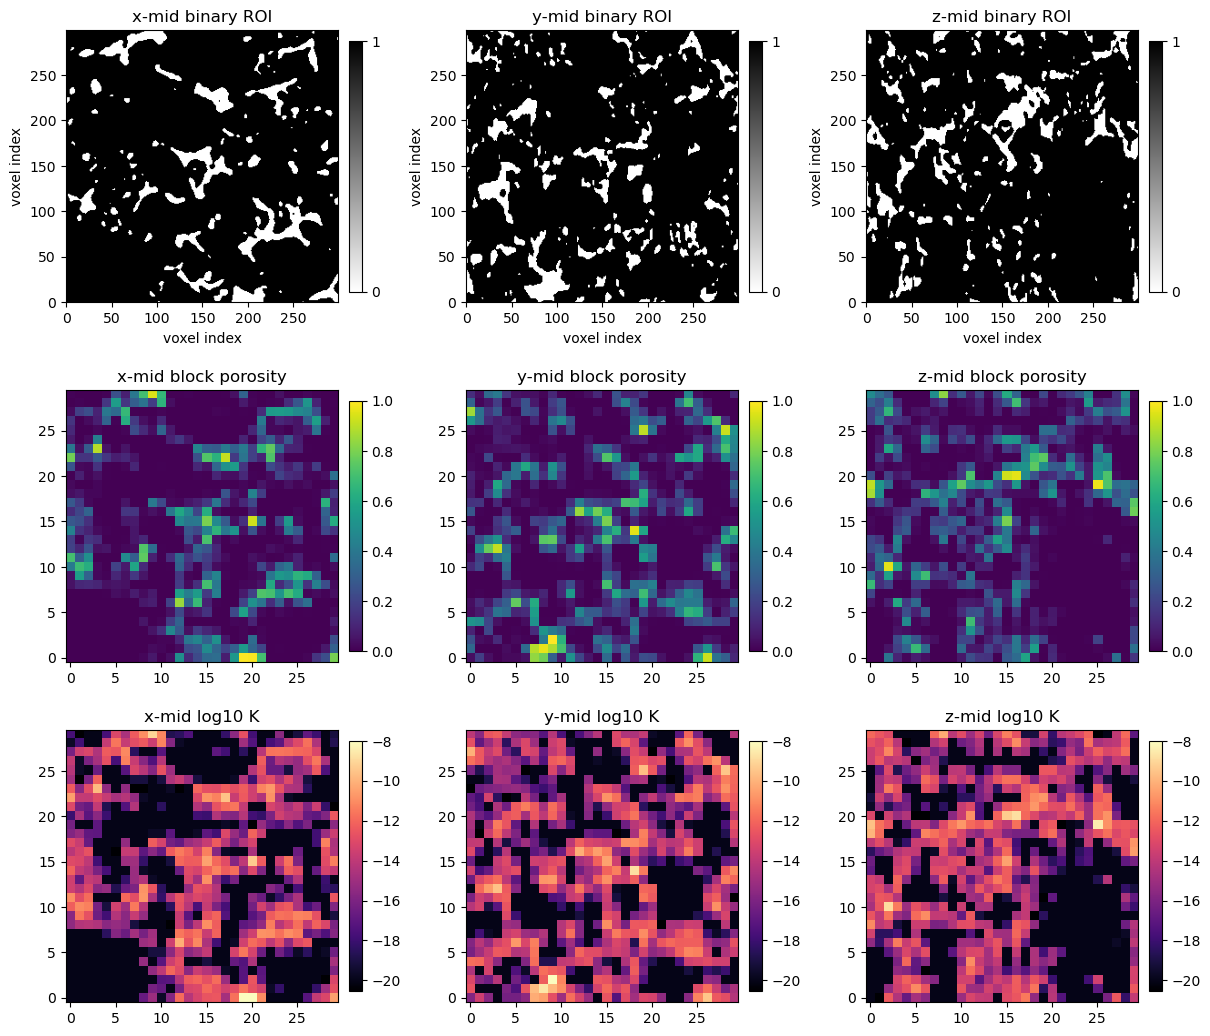

PosixPath('/prj/thermophase/volpatto/Work/voids/notebooks/outputs/44_mwe_drp317_parker_roi300_map30_same_roi_comparison/drp317_parker_roi300_map30_same_roi_binary_porosity_permeability_midplanes.png')

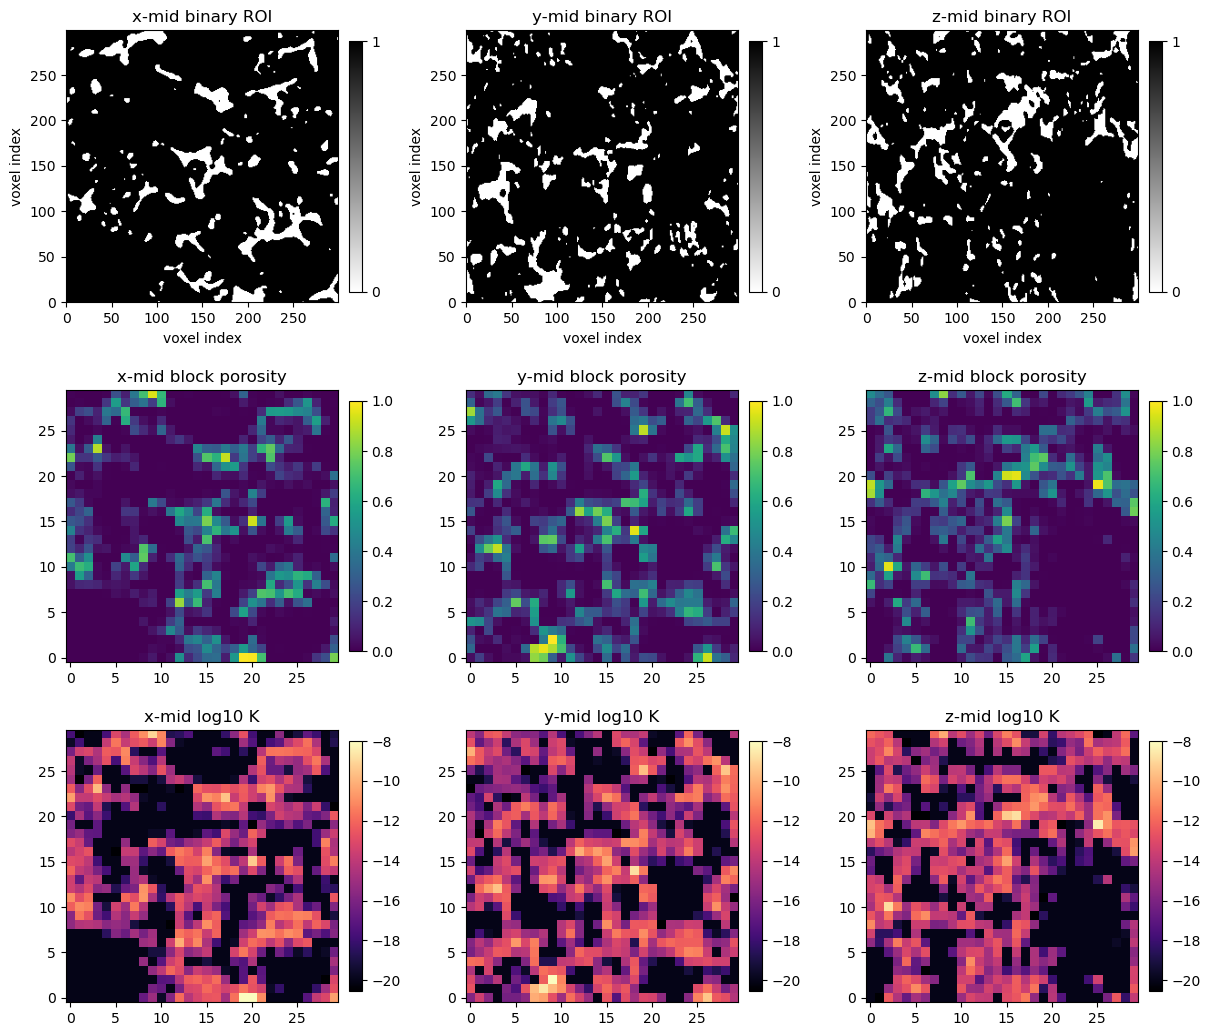

In [5]:
roi_mid = tuple(s // 2 for s in void_roi.shape)
mid = tuple(s // 2 for s in porosity_map.shape)
map_slice_specs = [
    (
        "x-mid",
        np.take(roi_raw, roi_mid[0], axis=0),
        np.take(porosity_map.values, mid[0], axis=0),
        np.take(permeability_map.values, mid[0], axis=0),
    ),
    (
        "y-mid",
        np.take(roi_raw, roi_mid[1], axis=1),
        np.take(porosity_map.values, mid[1], axis=1),
        np.take(permeability_map.values, mid[1], axis=1),
    ),
    (
        "z-mid",
        np.take(roi_raw, roi_mid[2], axis=2),
        np.take(porosity_map.values, mid[2], axis=2),
        np.take(permeability_map.values, mid[2], axis=2),
    ),
]

fig, axes = plt.subplots(3, 3, figsize=(12, 10.4), constrained_layout=True)
finite_log = np.log10(permeability_map.values[np.isfinite(permeability_map.values)])
for col, (title, binary_slice, porosity_slice, permeability_slice) in enumerate(
    map_slice_specs
):
    im_raw = axes[0, col].imshow(
        binary_slice.T,
        origin="lower",
        vmin=0,
        vmax=1,
        cmap="gray_r",
    )
    axes[0, col].set_title(f"{title} binary ROI")
    axes[0, col].set_xlabel("voxel index")
    axes[0, col].set_ylabel("voxel index")
    fig.colorbar(im_raw, ax=axes[0, col], ticks=[0, 1], fraction=0.046, pad=0.04)

    im0 = axes[1, col].imshow(
        porosity_slice.T, origin="lower", vmin=0.0, vmax=1.0, cmap="viridis"
    )
    axes[1, col].set_title(f"{title} block porosity")
    fig.colorbar(im0, ax=axes[1, col], fraction=0.046, pad=0.04)

    with np.errstate(divide="ignore"):
        log_perm = np.log10(permeability_slice)
    im1 = axes[2, col].imshow(
        log_perm.T,
        origin="lower",
        vmin=float(np.min(finite_log)),
        vmax=float(np.max(finite_log)),
        cmap="magma",
    )
    axes[2, col].set_title(f"{title} log10 K")
    fig.colorbar(im1, ax=axes[2, col], fraction=0.046, pad=0.04)

map_figure_path = (
    output_dir / f"{output_prefix}_binary_porosity_permeability_midplanes.png"
)
fig.savefig(map_figure_path, dpi=180)
display(fig)
map_figure_path

## Cell-centered TPFA Darcy-Darcy solve

In [6]:
resistor_results = {
    axis: solve_tpfa(
        permeability_map,
        flow_axis=axis,
        viscosity=mu_pa_s,
        pressure_inlet=pressure_inlet_pa,
        pressure_outlet=pressure_outlet_pa,
        solver_method=resistor_solver_method,
        solver_parameters=resistor_solver_parameters,
    )
    for axis in flow_axes
}

resistor_df = pd.DataFrame(
    [
        {
            "family": "map_resistor",
            "formulation": "darcy_darcy_tpfa_fv",
            "method": "TPFA finite-volume Darcy-Darcy",
            "axis": result.flow_axis,
            "mu_Pa_s": mu_pa_s,
            "pressure_inlet_Pa": pressure_inlet_pa,
            "pressure_outlet_Pa": pressure_outlet_pa,
            "delta_p_Pa": abs(pressure_inlet_pa - pressure_outlet_pa),
            "inlet_flux_m3_s": result.inlet_flow_rate,
            "outlet_flux_m3_s": result.outlet_flow_rate,
            "mass_imbalance_relative": result.mass_balance_error,
            "K_eq_m2": result.permeability,
            "K_eq_mD": result.permeability / M2_PER_MD,
            "matrix_nnz": result.matrix_nnz,
            "solve_seconds": result.solve_seconds,
            "solver_backend": (
                f"{result.solver_method}+{result.solver_info['preconditioner']}"
                if "preconditioner" in result.solver_info
                else result.solver_method
            ),
            "linear_residual_relative": result.residual_relative,
            "solver_info_json": json.dumps(result.solver_info, sort_keys=True),
        }
        for result in resistor_results.values()
    ]
)
display(resistor_df)

for axis, result in resistor_results.items():
    tpfa_velocity = reconstruct_tpfa_cell_velocity(
        result.pressure,
        permeability_map,
        flow_axis=axis,
        viscosity=mu_pa_s,
        pressure_inlet=pressure_inlet_pa,
        pressure_outlet=pressure_outlet_pa,
    )
    tpfa_vtu_path = output_dir / f"{output_prefix}_tpfa_velocity_{axis}.vtu"
    write_structured_vector_field(
        tpfa_velocity,
        porosity_map,
        tpfa_vtu_path,
        extra_cell_data={"pressure": result.pressure},
    )
    _record_field_output(
        family="map_resistor",
        formulation="darcy_darcy_tpfa_fv",
        method="TPFA finite-volume Darcy-Darcy",
        axis=axis,
        field="velocity",
        kind="paraview_vtu",
        path=tpfa_vtu_path,
    )

    pressure_plot_path = (
        output_dir / f"{output_prefix}_tpfa_pressure_midplanes_{axis}.png"
    )
    plotted_pressure = reference_pressure_to_outlet(
        result.pressure,
        flow_axis=axis,
        reference_pressure=reference_pressure_pa,
        pressure_outlet=pressure_outlet_pa,
    )
    pressure_fig = plot_scalar_midplanes(
        plotted_pressure,
        title=f"{sample_name} TPFA pressure, flow {axis}",
        path=pressure_plot_path,
        colorbar_label="pressure [Pa]",
        colorbar_use_offset=False,
    )
    plt.close(pressure_fig)
    _record_field_output(
        family="map_resistor",
        formulation="darcy_darcy_tpfa_fv",
        method="TPFA finite-volume Darcy-Darcy",
        axis=axis,
        field="pressure",
        kind="midplane_png",
        path=pressure_plot_path,
    )

    velocity_plot_path = (
        output_dir / f"{output_prefix}_tpfa_velocity_midplanes_{axis}.png"
    )
    velocity_fig = plot_vector_midplanes(
        tpfa_velocity,
        title=f"{sample_name} TPFA velocity, flow {axis}",
        path=velocity_plot_path,
        quiver_stride=3,
        colorbar_label="velocity magnitude [m/s]",
    )
    plt.close(velocity_fig)
    _record_field_output(
        family="map_resistor",
        formulation="darcy_darcy_tpfa_fv",
        method="TPFA finite-volume Darcy-Darcy",
        axis=axis,
        field="velocity",
        kind="midplane_quiver_png",
        path=velocity_plot_path,
    )

,family,formulation,method,axis,mu_Pa_s,pressure_inlet_Pa,pressure_outlet_Pa,delta_p_Pa,inlet_flux_m3_s,outlet_flux_m3_s,mass_imbalance_relative,K_eq_m2,K_eq_mD,matrix_nnz,solve_seconds,solver_backend,linear_residual_relative,solver_info_json
0,map_resistor,darcy_darcy_tpfa_fv,TPFA finite-volume Darcy-Darcy,x,0.001,1.0,0.0,1.0,8.895980e-15,8.895981e-15,1.478110e-07,1.317923e-14,13.353855,183600,1.272622,cg+pyamg,6.280664e-11,"{""info"": 0, ""linear_system_dtype"": ""float64"", ..."
1,map_resistor,darcy_darcy_tpfa_fv,TPFA finite-volume Darcy-Darcy,y,0.001,1.0,0.0,1.0,5.644066e-15,5.644070e-15,7.529025e-07,8.361585e-15,8.472376,183600,0.851852,cg+pyamg,9.262707e-11,"{""info"": 0, ""linear_system_dtype"": ""float64"", ..."
2,map_resistor,darcy_darcy_tpfa_fv,TPFA finite-volume Darcy-Darcy,z,0.001,1.0,0.0,1.0,1.336378e-14,1.336377e-14,2.170612e-07,1.979818e-14,20.060506,183600,0.865954,cg+pyamg,9.853169e-11,"{""info"": 0, ""linear_system_dtype"": ""float64"", ..."


## Same-ROI pore-network extraction and single-phase solves

In [7]:
_, axis_lengths, _, _ = infer_sample_axes(void_roi.shape, voxel_size=voxel_size_m)


def prepare_axis_image(image: np.ndarray, *, axis: str) -> np.ndarray:
    if not trim_nonpercolating_paths:
        return np.asarray(image, dtype=np.int8)
    axis_index = {"x": 0, "y": 1, "z": 2}[axis]
    trimmed = ps.filters.trim_nonpercolating_paths(
        np.asarray(image, dtype=bool), axis=axis_index
    )
    return trimmed.astype(np.int8)


pnm_rows: list[dict[str, object]] = []
pnm_failure_rows: list[dict[str, object]] = []

if pnm_requested and not run_pnm:
    for backend in pnm_backends:
        backend_label = str(pnm_backend_configs[backend]["label"])
        for axis in flow_axes:
            pnm_failure_rows.append(
                {
                    "backend": backend,
                    "method": backend_label,
                    "axis": axis,
                    "failure": pnm_skip_reason,
                    "elapsed_seconds": 0.0,
                }
            )
elif run_pnm:
    for backend in pnm_backends:
        backend_config = pnm_backend_configs[backend]
        backend_label = str(backend_config["label"])
        for axis in flow_axes:
            start = time.perf_counter()
            try:
                axis_image = prepare_axis_image(void_roi, axis=axis)
                if not np.any(axis_image):
                    raise RuntimeError(
                        f"No {axis}-percolating void voxels after trimming"
                    )
                extract = extract_spanning_pore_network(
                    axis_image,
                    voxel_size=voxel_size_m,
                    backend=backend,
                    flow_axis=axis,
                    length_unit="m",
                    geometry_repairs=backend_config.get("geometry_repairs"),
                    extraction_kwargs=dict(backend_config.get("extraction_kwargs", {})),
                    provenance_notes={
                        "raw_source": str(raw_relpath).replace("\\", "/"),
                        "roi_origin_voxels": roi_origin,
                        "roi_shape_voxels": roi_shape,
                        "map_target_shape_cells": map_target_shape,
                        "same_roi_comparison": True,
                        "trim_nonpercolating_paths": trim_nonpercolating_paths,
                    },
                )
                delta_p = pressure_gradient_pa_per_m * axis_lengths[axis]
                result = solve(
                    extract.net,
                    fluid=FluidSinglePhase(viscosity=mu_pa_s),
                    bc=PressureBC(
                        f"inlet_{axis}min",
                        f"outlet_{axis}max",
                        pin=delta_p,
                        pout=0.0,
                    ),
                    axis=axis,
                    options=SinglePhaseOptions(
                        conductance_model="generic_poiseuille", solver="direct"
                    ),
                )
                k_m2 = float(result.permeability[axis])
                pnm_rows.append(
                    {
                        "family": "extracted_pnm",
                        "formulation": "pore_network_model",
                        "method": backend_label,
                        "backend": backend,
                        "axis": axis,
                        "K_eq_m2": k_m2,
                        "K_eq_mD": k_m2 / M2_PER_MD,
                        "n_pores": float(extract.net.Np),
                        "n_throats": float(extract.net.Nt),
                        "mass_balance_error": float(result.mass_balance_error),
                        "solve_seconds": float(time.perf_counter() - start),
                    }
                )
            except Exception as exc:
                pnm_failure_rows.append(
                    {
                        "backend": backend,
                        "method": backend_label,
                        "axis": axis,
                        "failure": f"{type(exc).__name__}: {exc}",
                        "elapsed_seconds": float(time.perf_counter() - start),
                    }
                )

pnm_columns = [
    "family",
    "formulation",
    "method",
    "backend",
    "axis",
    "K_eq_m2",
    "K_eq_mD",
    "n_pores",
    "n_throats",
    "mass_balance_error",
    "solve_seconds",
]
pnm_df = pd.DataFrame(pnm_rows, columns=pnm_columns)
pnm_failure_columns = ["backend", "method", "axis", "failure", "elapsed_seconds"]
pnm_failures = pd.DataFrame(pnm_failure_rows, columns=pnm_failure_columns)
display(pnm_df)
if not pnm_failures.empty:
    display(pnm_failures)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


,family,formulation,method,backend,axis,K_eq_m2,K_eq_mD,n_pores,n_throats,mass_balance_error,solve_seconds
0,extracted_pnm,pore_network_model,PoreSpy snow2,porespy,x,1.138010e-14,11.530886,4903.0,7819.0,2.517895e-26,65.589808
1,extracted_pnm,pore_network_model,PoreSpy snow2,porespy,y,1.044781e-14,10.586242,4903.0,7819.0,5.118183e-27,64.967160
2,extracted_pnm,pore_network_model,PoreSpy snow2,porespy,z,1.731528e-14,17.544707,4903.0,7819.0,1.260681e-26,64.925270
3,extracted_pnm,pore_network_model,PREGO,prego,x,2.401953e-14,24.337790,3539.0,7427.0,1.083082e-26,74.300938
4,extracted_pnm,pore_network_model,PREGO,prego,y,2.072689e-14,21.001525,3539.0,7427.0,5.745868e-27,74.442722
5,extracted_pnm,pore_network_model,PREGO,prego,z,3.476085e-14,35.221430,3539.0,7427.0,1.731834e-26,74.254868
6,extracted_pnm,pore_network_model,Native maximal-ball,native_maximal_ball,x,4.199920e-15,4.255568,3217.0,5150.0,3.945392e-27,28.140258
7,extracted_pnm,pore_network_model,Native maximal-ball,native_maximal_ball,y,4.175967e-15,4.231298,3217.0,5150.0,1.715148e-27,27.550368
8,extracted_pnm,pore_network_model,Native maximal-ball,native_maximal_ball,z,6.022421e-15,6.102218,3217.0,5150.0,3.068881e-27,28.019042


## Direct-image LBM DNS

This row solves the binary ROI directly with XLB. It does not use the
Kozeny-Carman porosity/permeability map, so it is a DNS-style reference row
rather than another map-based Darcy or Brinkman discretization. The solve runs
in a short-lived worker process so JAX/XLB releases GPU memory before the
cuDSS-backed FEM stage starts.

In [8]:
lbm_df, lbm_status, lbm_field_outputs = run_or_load_lbm_artifacts(void_roi)
append_lbm_field_outputs(lbm_field_outputs)
display(lbm_df)

,family,formulation,method,solver_backend,axis,K_m2,K_mD,solve_seconds,xlb_steps,xlb_converged,xlb_convergence_metric,xlb_mach_max,xlb_re_voxel_max,xlb_lattice_viscosity,xlb_pressure_drop_lattice,warning_count,warnings


## FEniCSx FEM micro-continuum solves

In [9]:
fem_directional_path = output_dir / f"{output_prefix}_fenicsx_fem_directional.csv"
fem_status_path = output_dir / f"{output_prefix}_fem_status.json"
fem_run_specs: list[dict[str, Any]] = [
    {
        "label": "usfem_brinkman_direct",
        "solver": solve_brinkman_usfem,
        "family": "fem_micro_continuum",
        "formulation": "brinkman_usfem_p1dg1",
        "method": "Darcy-Brinkman micro-continuum USFEM CG1 x DG1",
        "solver_backends": fem_usfem_solver_backends,
        "solver_kwargs": fem_brinkman_solver_kwargs,
    },
    {
        "label": "taylor_hood_brinkman_direct",
        "solver": solve_brinkman_taylor_hood,
        "family": "fem_micro_continuum",
        "formulation": "brinkman_taylor_hood_p2p1",
        "method": "Darcy-Brinkman coefficient-field Taylor-Hood CG2 x CG1",
        "solver_backends": fem_taylor_hood_solver_backends,
        "solver_kwargs": fem_brinkman_solver_kwargs,
    },
    {
        "label": "taylor_hood_darcy_direct",
        "solver": solve_darcy_taylor_hood,
        "family": "fem_coefficient_field",
        "formulation": "darcy_taylor_hood_p2p1",
        "method": "Darcy-Darcy coefficient-field Taylor-Hood CG2 x CG1",
        "solver_backends": fem_taylor_hood_solver_backends,
    },
]

fem_status: dict[str, Any] = {
    "requested": bool(run_fem),
    "backend": "voids.fem.singlephase",
    "direct_solver_backends": {
        "usfem": fem_usfem_solver_backends,
        "taylor_hood": fem_taylor_hood_solver_backends,
    },
    "direct_base_options": fem_direct_base_options,
    "thread_env": {
        "OMP_NUM_THREADS": os.environ.get("OMP_NUM_THREADS"),
        "OPENBLAS_NUM_THREADS": os.environ.get("OPENBLAS_NUM_THREADS"),
        "VECLIB_MAXIMUM_THREADS": os.environ.get("VECLIB_MAXIMUM_THREADS"),
        "MKL_NUM_THREADS": os.environ.get("MKL_NUM_THREADS"),
        "NUMEXPR_NUM_THREADS": os.environ.get("NUMEXPR_NUM_THREADS"),
    },
    "runs": [],
    "status": "not_requested" if not run_fem else "pending",
}

if run_fem:
    fem_problem = FEMMapProblem(
        permeability_map=permeability_map,
        porosity_map=porosity_map,
        viscosity=mu_pa_s,
        porosity_floor=fem_porosity_floor,
        permeability_floor=fem_k_floor,
    )
    fem_rows: list[dict[str, object]] = []
    try:
        for spec in fem_run_specs:
            for axis in flow_axes:
                attempts: list[dict[str, object]] = []
                last_exception: Exception | None = None
                for backend in spec["solver_backends"]:
                    solver_options = fem_direct_solver_options(backend)
                    start = time.perf_counter()
                    try:
                        result = spec["solver"](
                            fem_problem,
                            flow_axis=axis,
                            pressure_inlet=pressure_inlet_pa,
                            pressure_outlet=pressure_outlet_pa,
                            options=solver_options,
                            **dict(spec.get("solver_kwargs", {})),
                        )
                    except Exception as exc:
                        last_exception = exc
                        attempts.append(
                            {
                                "backend": backend,
                                "wall_seconds": time.perf_counter() - start,
                                "status": "failed",
                                "message": f"{type(exc).__name__}: {exc}",
                            }
                        )
                        continue
                    wall_seconds = time.perf_counter() - start
                    attempts.append(
                        {
                            "backend": backend,
                            "wall_seconds": wall_seconds,
                            "reported_solve_seconds": result.solve_seconds,
                            "status": "ok",
                        }
                    )
                    row = {
                        "family": spec["family"],
                        "formulation": spec["formulation"],
                        "method": spec["method"],
                        "solver_backend": fem_backend_label(backend),
                        "axis": result.flow_axis,
                        "mu_Pa_s": mu_pa_s,
                        "pressure_inlet_Pa": result.pressure_inlet,
                        "pressure_outlet_Pa": result.pressure_outlet,
                        "delta_p_Pa": result.pressure_drop,
                        "outlet_flux_m3_s": result.flow_rate,
                        "K_eq_m2": result.permeability,
                        "K_eq_mD": result.permeability / M2_PER_MD,
                        "solve_seconds": result.solve_seconds,
                        "wall_seconds": wall_seconds,
                        "solver_options_json": json.dumps(
                            solver_options.petsc_options,
                            sort_keys=True,
                        ),
                        "metadata_json": json.dumps(result.metadata, sort_keys=True),
                    }
                    field_stem = f"{output_prefix}_{spec['formulation']}_{axis}"
                    fem_velocity_path = output_dir / f"{field_stem}_velocity.xdmf"
                    fem_pressure_path = output_dir / f"{field_stem}_pressure.xdmf"
                    write_dolfinx_function_xdmf(
                        result.velocity,
                        fem_velocity_path,
                        name=f"{spec['formulation']}_{axis}_velocity",
                    )
                    write_dolfinx_function_xdmf(
                        result.pressure,
                        fem_pressure_path,
                        name=f"{spec['formulation']}_{axis}_pressure",
                    )
                    _record_field_output(
                        family=str(spec["family"]),
                        formulation=str(spec["formulation"]),
                        method=str(spec["method"]),
                        axis=axis,
                        field="velocity",
                        kind="paraview_xdmf",
                        path=fem_velocity_path,
                    )
                    _record_field_output(
                        family=str(spec["family"]),
                        formulation=str(spec["formulation"]),
                        method=str(spec["method"]),
                        axis=axis,
                        field="pressure",
                        kind="paraview_xdmf",
                        path=fem_pressure_path,
                    )

                    sampled_pressure = sample_dolfinx_function_on_grid(
                        result.pressure,
                        shape=porosity_map.shape,
                        cell_size=porosity_map.cell_size,
                        origin=porosity_map.origin,
                    )
                    sampled_velocity = sample_dolfinx_function_on_grid(
                        result.velocity,
                        shape=porosity_map.shape,
                        cell_size=porosity_map.cell_size,
                        origin=porosity_map.origin,
                    )
                    pressure_plot_path = (
                        output_dir / f"{field_stem}_pressure_midplanes.png"
                    )
                    plotted_pressure = reference_pressure_to_outlet(
                        sampled_pressure,
                        flow_axis=axis,
                        reference_pressure=reference_pressure_pa,
                        pressure_outlet=pressure_outlet_pa,
                    )
                    pressure_fig = plot_scalar_midplanes(
                        plotted_pressure,
                        title=f"{sample_name} {spec['method']} pressure, flow {axis}",
                        path=pressure_plot_path,
                        colorbar_label="pressure [Pa]",
                        colorbar_use_offset=False,
                    )
                    plt.close(pressure_fig)
                    _record_field_output(
                        family=str(spec["family"]),
                        formulation=str(spec["formulation"]),
                        method=str(spec["method"]),
                        axis=axis,
                        field="pressure",
                        kind="midplane_png",
                        path=pressure_plot_path,
                    )

                    velocity_plot_path = (
                        output_dir / f"{field_stem}_velocity_midplanes.png"
                    )
                    velocity_fig = plot_vector_midplanes(
                        sampled_velocity,
                        title=f"{sample_name} {spec['method']} velocity, flow {axis}",
                        path=velocity_plot_path,
                        quiver_stride=3,
                        colorbar_label="velocity magnitude [m/s]",
                    )
                    plt.close(velocity_fig)
                    _record_field_output(
                        family=str(spec["family"]),
                        formulation=str(spec["formulation"]),
                        method=str(spec["method"]),
                        axis=axis,
                        field="velocity",
                        kind="midplane_quiver_png",
                        path=velocity_plot_path,
                    )
                    fem_rows.append(row)
                    fem_status["runs"].append(
                        {
                            "label": spec["label"],
                            "axis": axis,
                            "attempts": attempts,
                            "status": "ok",
                        }
                    )
                    pd.DataFrame(fem_rows).to_csv(fem_directional_path, index=False)
                    fem_status_path.write_text(
                        json.dumps(fem_status, indent=2),
                        encoding="utf-8",
                    )
                    break
                else:
                    fem_status["runs"].append(
                        {
                            "label": spec["label"],
                            "axis": axis,
                            "attempts": attempts,
                            "status": "failed",
                        }
                    )
                    raise RuntimeError(
                        f"All direct FEM solver backends failed for {spec['label']} axis {axis}"
                    ) from last_exception
        fem_status["status"] = "ok"
    except Exception as exc:
        fem_status["status"] = "failed"
        fem_status["message"] = f"{type(exc).__name__}: {exc}"
        fem_status_path.write_text(json.dumps(fem_status, indent=2), encoding="utf-8")
        raise
    fem_df = pd.DataFrame(fem_rows)
    fem_df.to_csv(fem_directional_path, index=False)
elif fem_directional_path.exists():
    fem_df = pd.read_csv(fem_directional_path)
    fem_status["status"] = "loaded_existing"
else:
    fem_df = pd.DataFrame()
    fem_status["status"] = "missing"

display(fem_status)
display(fem_df)

{'requested': True,
 'backend': 'voids.fem.singlephase',
 'direct_solver_backends': {'usfem': ('nvmath_cudss',),
  'taylor_hood': ('nvmath_cudss',)},
 'direct_base_options': {'ksp_type': 'preonly',
  'pc_type': 'lu',
  'pc_factor_shift_type': 'nonzero',
  'pc_factor_shift_amount': 1e-12,
  'ksp_error_if_not_converged': True},
 'thread_env': {'OMP_NUM_THREADS': '1',
  'OPENBLAS_NUM_THREADS': '1',
  'VECLIB_MAXIMUM_THREADS': '1',
  'MKL_NUM_THREADS': '1',
  'NUMEXPR_NUM_THREADS': '1'},
 'runs': [{'label': 'usfem_brinkman_direct',
   'axis': 'x',
   'attempts': [{'backend': 'nvmath_cudss',
     'wall_seconds': 203.9269509629812,
     'reported_solve_seconds': 201.23496882303152,
     'status': 'ok'}],
   'status': 'ok'},
  {'label': 'usfem_brinkman_direct',
   'axis': 'y',
   'attempts': [{'backend': 'nvmath_cudss',
     'wall_seconds': 200.74669187597465,
     'reported_solve_seconds': 199.260899640969,
     'status': 'ok'}],
   'status': 'ok'},
  {'label': 'usfem_brinkman_direct',
   'a

,family,formulation,method,solver_backend,axis,mu_Pa_s,pressure_inlet_Pa,pressure_outlet_Pa,delta_p_Pa,outlet_flux_m3_s,K_eq_m2,K_eq_mD,solve_seconds,wall_seconds,solver_options_json,metadata_json
0,fem_micro_continuum,brinkman_usfem_p1dg1,Darcy-Brinkman micro-continuum USFEM CG1 x DG1,fenicsx:nvmath-cudss-float64,x,0.001,1.0,0.0,1.0,2.297851e-15,3.404223e-15,3.449329,201.234969,203.926951,"{""ksp_error_if_not_converged"": true, ""ksp_type...","{""alpha_edge"": 1.0, ""linear_backend"": ""nvmath_..."
1,fem_micro_continuum,brinkman_usfem_p1dg1,Darcy-Brinkman micro-continuum USFEM CG1 x DG1,fenicsx:nvmath-cudss-float64,y,0.001,1.0,0.0,1.0,1.164725e-15,1.725518e-15,1.748381,199.260900,200.746692,"{""ksp_error_if_not_converged"": true, ""ksp_type...","{""alpha_edge"": 1.0, ""linear_backend"": ""nvmath_..."
2,fem_micro_continuum,brinkman_usfem_p1dg1,Darcy-Brinkman micro-continuum USFEM CG1 x DG1,fenicsx:nvmath-cudss-float64,z,0.001,1.0,0.0,1.0,3.576208e-15,5.298086e-15,5.368285,202.715097,204.193574,"{""ksp_error_if_not_converged"": true, ""ksp_type...","{""alpha_edge"": 1.0, ""linear_backend"": ""nvmath_..."
3,fem_micro_continuum,brinkman_taylor_hood_p2p1,Darcy-Brinkman coefficient-field Taylor-Hood C...,fenicsx:nvmath-cudss-float64,x,0.001,1.0,0.0,1.0,1.566474e-14,2.320702e-14,23.514513,190.313890,197.615117,"{""ksp_error_if_not_converged"": true, ""ksp_type...","{""linear_backend"": ""nvmath_cudss"", ""linear_sys..."
4,fem_micro_continuum,brinkman_taylor_hood_p2p1,Darcy-Brinkman coefficient-field Taylor-Hood C...,fenicsx:nvmath-cudss-float64,y,0.001,1.0,0.0,1.0,1.014586e-14,1.503090e-14,15.230057,194.241068,201.634240,"{""ksp_error_if_not_converged"": true, ""ksp_type...","{""linear_backend"": ""nvmath_cudss"", ""linear_sys..."
5,fem_micro_continuum,brinkman_taylor_hood_p2p1,Darcy-Brinkman coefficient-field Taylor-Hood C...,fenicsx:nvmath-cudss-float64,z,0.001,1.0,0.0,1.0,2.170087e-14,3.214944e-14,32.575420,184.205112,191.628354,"{""ksp_error_if_not_converged"": true, ""ksp_type...","{""linear_backend"": ""nvmath_cudss"", ""linear_sys..."
6,fem_coefficient_field,darcy_taylor_hood_p2p1,Darcy-Darcy coefficient-field Taylor-Hood CG2 ...,fenicsx:nvmath-cudss-float64,x,0.001,1.0,0.0,1.0,1.856357e-14,2.750158e-14,27.865978,193.593632,200.576448,"{""ksp_error_if_not_converged"": true, ""ksp_type...","{""linear_backend"": ""nvmath_cudss"", ""linear_sys..."
7,fem_coefficient_field,darcy_taylor_hood_p2p1,Darcy-Darcy coefficient-field Taylor-Hood CG2 ...,fenicsx:nvmath-cudss-float64,y,0.001,1.0,0.0,1.0,1.145310e-14,1.696756e-14,17.192380,191.322178,198.630032,"{""ksp_error_if_not_converged"": true, ""ksp_type...","{""linear_backend"": ""nvmath_cudss"", ""linear_sys..."
8,fem_coefficient_field,darcy_taylor_hood_p2p1,Darcy-Darcy coefficient-field Taylor-Hood CG2 ...,fenicsx:nvmath-cudss-float64,z,0.001,1.0,0.0,1.0,2.694709e-14,3.992161e-14,40.450573,191.059198,197.985906,"{""ksp_error_if_not_converged"": true, ""ksp_type...","{""linear_backend"": ""nvmath_cudss"", ""linear_sys..."


## Direct-image LBM DNS artifacts

The XLB solve is run before FEM in an isolated worker process; this cell
reloads the rendered table after the FEM stage.

In [10]:
lbm_df, lbm_status, lbm_field_outputs = run_or_load_lbm_artifacts(void_roi)
append_lbm_field_outputs(lbm_field_outputs)
display(lbm_df)

,family,formulation,method,solver_backend,axis,K_m2,K_mD,solve_seconds,xlb_steps,xlb_converged,xlb_convergence_metric,xlb_mach_max,xlb_re_voxel_max,xlb_lattice_viscosity,xlb_pressure_drop_lattice,warning_count,warnings


## Compare all rows from the same ROI

In [11]:
comparison_rows: list[dict[str, object]] = []


for row in resistor_df.to_dict(orient="records"):
    comparison_rows.append(
        {
            "family": row["family"],
            "formulation": row["formulation"],
            "method": row["method"],
            "solver_backend": row.get("solver_backend", ""),
            "axis": row["axis"],
            "K_m2": float(row["K_eq_m2"]),
            "K_mD": float(row["K_eq_mD"]),
            "solve_seconds": float(row["solve_seconds"]),
        }
    )

if not fem_df.empty:
    for row in fem_df.to_dict(orient="records"):
        comparison_rows.append(
            {
                "family": row["family"],
                "formulation": row["formulation"],
                "method": row["method"],
                "solver_backend": row.get("solver_backend", ""),
                "axis": row["axis"],
                "K_m2": float(row["K_eq_m2"]),
                "K_mD": float(row["K_eq_mD"]),
                "solve_seconds": float(row["solve_seconds"]),
            }
        )

if not lbm_df.empty:
    for row in lbm_df.to_dict(orient="records"):
        comparison_rows.append(
            {
                "family": row["family"],
                "formulation": row["formulation"],
                "method": row["method"],
                "solver_backend": row.get("solver_backend", ""),
                "axis": row["axis"],
                "K_m2": float(row["K_m2"]),
                "K_mD": float(row["K_mD"]),
                "solve_seconds": float(row["solve_seconds"]),
            }
        )

if not pnm_df.empty:
    for row in pnm_df.to_dict(orient="records"):
        comparison_rows.append(
            {
                "family": row["family"],
                "formulation": row["formulation"],
                "method": row["method"],
                "solver_backend": "",
                "axis": row["axis"],
                "K_m2": float(row["K_eq_m2"]),
                "K_mD": float(row["K_eq_mD"]),
                "solve_seconds": float(row["solve_seconds"]),
            }
        )

for axis in flow_axes:
    comparison_rows.append(
        {
            "family": "experimental",
            "formulation": "bulk_experiment",
            "method": "Experimental Kabs",
            "solver_backend": "",
            "axis": axis,
            "K_m2": experimental_kabs_mD * M2_PER_MD,
            "K_mD": experimental_kabs_mD,
            "solve_seconds": np.nan,
        }
    )

comparison_df = pd.DataFrame(comparison_rows)
ratio_df = comparison_df.assign(
    K_experimental_mD=experimental_kabs_mD,
    method_over_experiment=comparison_df["K_mD"] / experimental_kabs_mD,
    experiment_over_method=experimental_kabs_mD / comparison_df["K_mD"],
)
display(comparison_df.sort_values(["axis", "family", "method"]))
display(ratio_df.sort_values(["axis", "family", "method"]))

,family,formulation,method,solver_backend,axis,K_m2,K_mD,solve_seconds
21,experimental,bulk_experiment,Experimental Kabs,,x,9.869233e-15,10.000000,NaN
18,extracted_pnm,pore_network_model,Native maximal-ball,,x,4.199920e-15,4.255568,28.140258
15,extracted_pnm,pore_network_model,PREGO,,x,2.401953e-14,24.337790,74.300938
12,extracted_pnm,pore_network_model,PoreSpy snow2,,x,1.138010e-14,11.530886,65.589808
9,fem_coefficient_field,darcy_taylor_hood_p2p1,Darcy-Darcy coefficient-field Taylor-Hood CG2 ...,fenicsx:nvmath-cudss-float64,x,2.750158e-14,27.865978,193.593632
6,fem_micro_continuum,brinkman_taylor_hood_p2p1,Darcy-Brinkman coefficient-field Taylor-Hood C...,fenicsx:nvmath-cudss-float64,x,2.320702e-14,23.514513,190.313890
3,fem_micro_continuum,brinkman_usfem_p1dg1,Darcy-Brinkman micro-continuum USFEM CG1 x DG1,fenicsx:nvmath-cudss-float64,x,3.404223e-15,3.449329,201.234969
0,map_resistor,darcy_darcy_tpfa_fv,TPFA finite-volume Darcy-Darcy,cg+pyamg,x,1.317923e-14,13.353855,1.272622
22,experimental,bulk_experiment,Experimental Kabs,,y,9.869233e-15,10.000000,NaN
19,extracted_pnm,pore_network_model,Native maximal-ball,,y,4.175967e-15,4.231298,27.550368


,family,formulation,method,solver_backend,axis,K_m2,K_mD,solve_seconds,K_experimental_mD,method_over_experiment,experiment_over_method
21,experimental,bulk_experiment,Experimental Kabs,,x,9.869233e-15,10.000000,NaN,10.0,1.000000,1.000000
18,extracted_pnm,pore_network_model,Native maximal-ball,,x,4.199920e-15,4.255568,28.140258,10.0,0.425557,2.349862
15,extracted_pnm,pore_network_model,PREGO,,x,2.401953e-14,24.337790,74.300938,10.0,2.433779,0.410884
12,extracted_pnm,pore_network_model,PoreSpy snow2,,x,1.138010e-14,11.530886,65.589808,10.0,1.153089,0.867236
9,fem_coefficient_field,darcy_taylor_hood_p2p1,Darcy-Darcy coefficient-field Taylor-Hood CG2 ...,fenicsx:nvmath-cudss-float64,x,2.750158e-14,27.865978,193.593632,10.0,2.786598,0.358861
6,fem_micro_continuum,brinkman_taylor_hood_p2p1,Darcy-Brinkman coefficient-field Taylor-Hood C...,fenicsx:nvmath-cudss-float64,x,2.320702e-14,23.514513,190.313890,10.0,2.351451,0.425269
3,fem_micro_continuum,brinkman_usfem_p1dg1,Darcy-Brinkman micro-continuum USFEM CG1 x DG1,fenicsx:nvmath-cudss-float64,x,3.404223e-15,3.449329,201.234969,10.0,0.344933,2.899115
0,map_resistor,darcy_darcy_tpfa_fv,TPFA finite-volume Darcy-Darcy,cg+pyamg,x,1.317923e-14,13.353855,1.272622,10.0,1.335386,0.748847
22,experimental,bulk_experiment,Experimental Kabs,,y,9.869233e-15,10.000000,NaN,10.0,1.000000,1.000000
19,extracted_pnm,pore_network_model,Native maximal-ball,,y,4.175967e-15,4.231298,27.550368,10.0,0.423130,2.363341


In [12]:
axis_order = ["x", "y", "z"]
method_order = [
    "Experimental Kabs",
    "Direct-image LBM DNS (XLB, Stokes-limit preset)",
    "Darcy-Brinkman micro-continuum USFEM CG1 x DG1",
    "Darcy-Brinkman coefficient-field Taylor-Hood CG2 x CG1",
    "Darcy-Darcy coefficient-field Taylor-Hood CG2 x CG1",
    "TPFA finite-volume Darcy-Darcy",
    "PoreSpy snow2",
    "PREGO",
    "Native maximal-ball",
]
available_methods = [
    method for method in method_order if method in set(comparison_df["method"])
]

### Bulk scalar summaries

The experimental reference is reported as a scalar bulk permeability. The
directional simulations estimate \(K_x\), \(K_y\), and \(K_z\) on a small,
anisotropic ROI. The arithmetic and harmonic means below are therefore scalar
summaries of the directional values, not replacements for the directional
permeability tensor:

\[
K_\mathrm{arith} = \frac{K_x + K_y + K_z}{3},
\qquad
K_\mathrm{harm} = \frac{3}{1/K_x + 1/K_y + 1/K_z}.
\]

,method,family,formulation,solver_backend,K_arithmetic_mean_mD,K_harmonic_mean_mD,K_arithmetic_over_experiment,K_harmonic_over_experiment,K_max_over_min
0,Darcy-Brinkman micro-continuum USFEM CG1 x DG1,fem_micro_continuum,brinkman_usfem_p1dg1,fenicsx:nvmath-cudss-float64,3.521998,2.862190,0.352200,0.286219,3.070432
1,Darcy-Brinkman coefficient-field Taylor-Hood C...,fem_micro_continuum,brinkman_taylor_hood_p2p1,fenicsx:nvmath-cudss-float64,23.773330,21.600674,2.377333,2.160067,2.138890
2,Darcy-Darcy coefficient-field Taylor-Hood CG2 ...,fem_coefficient_field,darcy_taylor_hood_p2p1,fenicsx:nvmath-cudss-float64,28.502977,25.258290,2.850298,2.525829,2.352820
3,TPFA finite-volume Darcy-Darcy,map_resistor,darcy_darcy_tpfa_fv,cg+pyamg,13.962246,12.357651,1.396225,1.235765,2.367755
4,PoreSpy snow2,extracted_pnm,pore_network_model,,13.220612,12.595353,1.322061,1.259535,1.657312
5,PREGO,extracted_pnm,pore_network_model,,26.853582,25.620057,2.685358,2.562006,1.677089
6,Native maximal-ball,extracted_pnm,pore_network_model,,4.863028,4.722958,0.486303,0.472296,1.442162


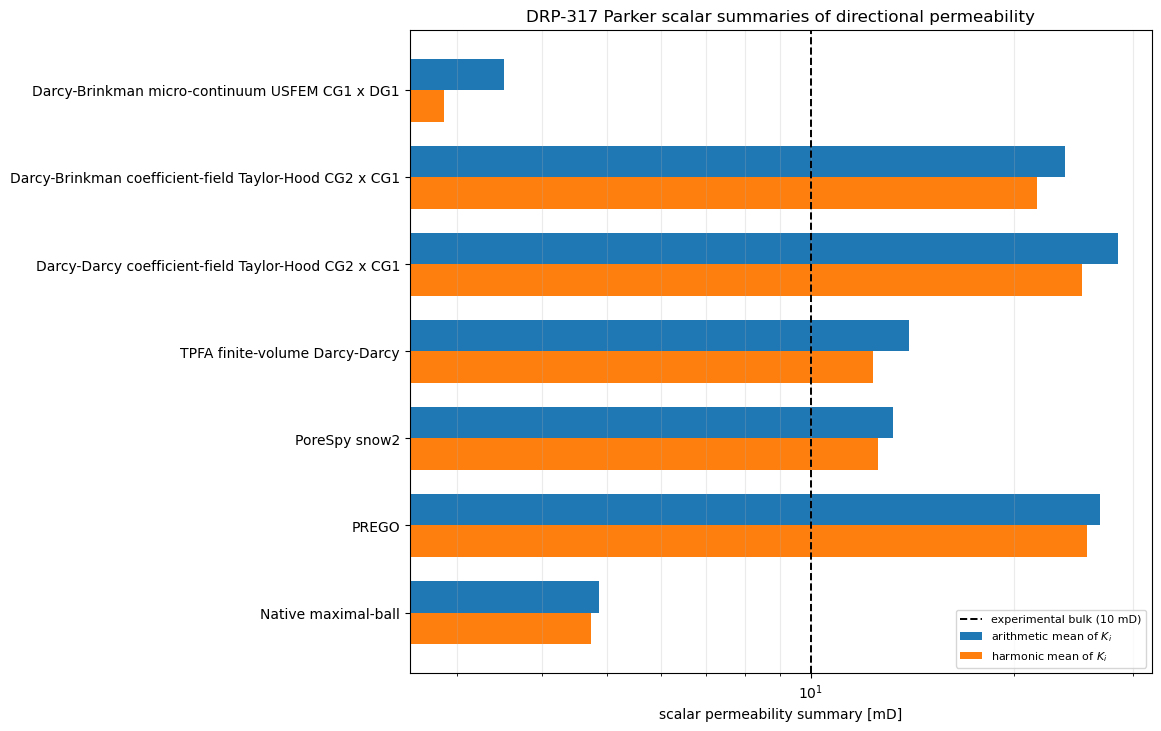

PosixPath('/prj/thermophase/volpatto/Work/voids/notebooks/outputs/44_mwe_drp317_parker_roi300_map30_same_roi_comparison/drp317_parker_roi300_map30_same_roi_bulk_permeability_means.png')

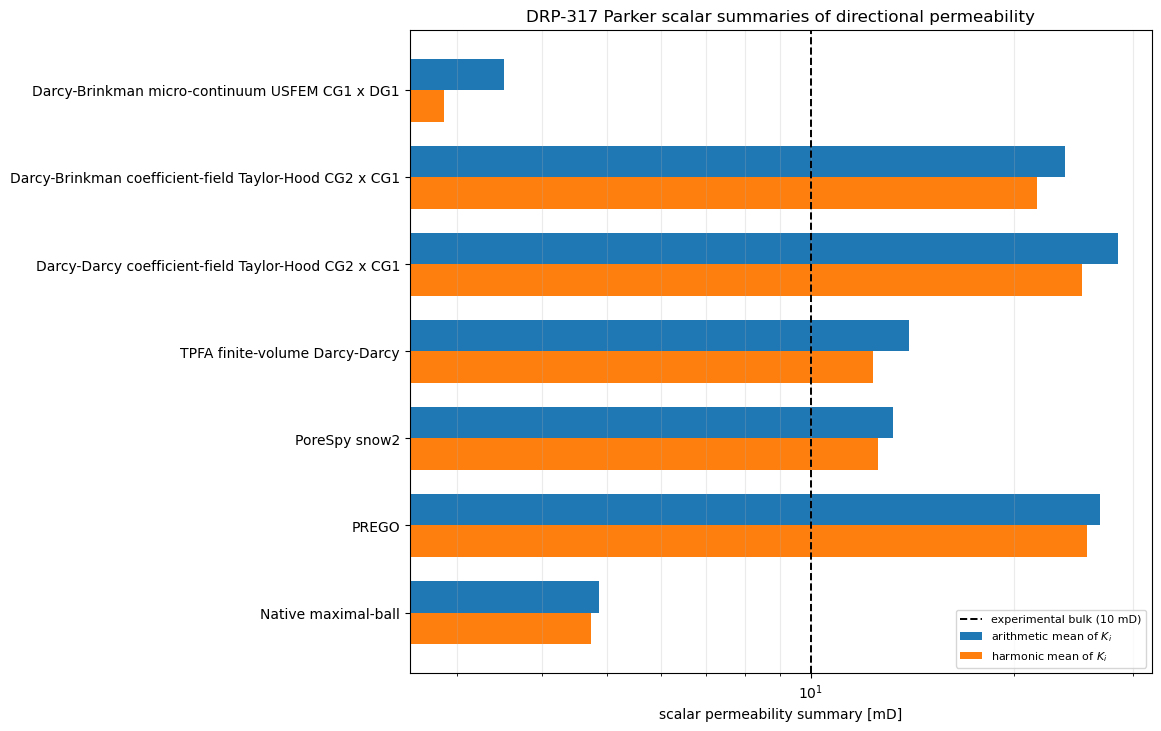

In [13]:
bulk_records: list[dict[str, Any]] = []
for method in available_methods:
    if method == "Experimental Kabs":
        continue
    subset = comparison_df[comparison_df["method"] == method].set_index("axis")
    if not all(axis in subset.index for axis in axis_order):
        continue
    values = np.asarray(
        [float(subset.loc[axis, "K_mD"]) for axis in axis_order], dtype=float
    )
    if not np.all(np.isfinite(values)) or np.any(values <= 0.0):
        continue
    first = subset.loc[axis_order[0]]
    arithmetic_mean_mD = float(np.mean(values))
    harmonic_mean_mD = float(len(values) / np.sum(1.0 / values))
    bulk_records.append(
        {
            "family": str(first["family"]),
            "formulation": str(first["formulation"]),
            "method": method,
            "solver_backend": (
                "" if pd.isna(first["solver_backend"]) else str(first["solver_backend"])
            ),
            "K_arithmetic_mean_mD": arithmetic_mean_mD,
            "K_harmonic_mean_mD": harmonic_mean_mD,
            "K_arithmetic_over_experiment": arithmetic_mean_mD / experimental_kabs_mD,
            "K_harmonic_over_experiment": harmonic_mean_mD / experimental_kabs_mD,
            "K_max_over_min": float(np.max(values) / np.min(values)),
        }
    )

bulk_summary_df = pd.DataFrame(bulk_records)
bulk_summary_df = (
    bulk_summary_df.set_index("method")
    .reindex([method for method in available_methods if method != "Experimental Kabs"])
    .dropna(how="all")
    .reset_index()
)
display(bulk_summary_df)

fig, ax = plt.subplots(figsize=(11.5, 7.2), constrained_layout=True)
y_positions = np.arange(len(bulk_summary_df), dtype=float)
bar_height = 0.36
ax.barh(
    y_positions - 0.5 * bar_height,
    bulk_summary_df["K_arithmetic_mean_mD"],
    height=bar_height,
    label=r"arithmetic mean of $K_i$",
)
ax.barh(
    y_positions + 0.5 * bar_height,
    bulk_summary_df["K_harmonic_mean_mD"],
    height=bar_height,
    label=r"harmonic mean of $K_i$",
)
ax.axvline(
    experimental_kabs_mD,
    color="black",
    linestyle="--",
    linewidth=1.4,
    label=f"experimental bulk ({experimental_kabs_mD:.0f} mD)",
)
ax.set_xscale("log")
ax.set_yticks(y_positions)
ax.set_yticklabels(bulk_summary_df["method"])
ax.invert_yaxis()
ax.set_xlabel("scalar permeability summary [mD]")
ax.set_title("DRP-317 Parker scalar summaries of directional permeability")
ax.grid(True, axis="x", which="both", alpha=0.25)
ax.legend(fontsize=8, loc="lower right")

bulk_plot_path = output_dir / f"{output_prefix}_bulk_permeability_means.png"
fig.savefig(bulk_plot_path, dpi=200)
display(fig)
bulk_plot_path

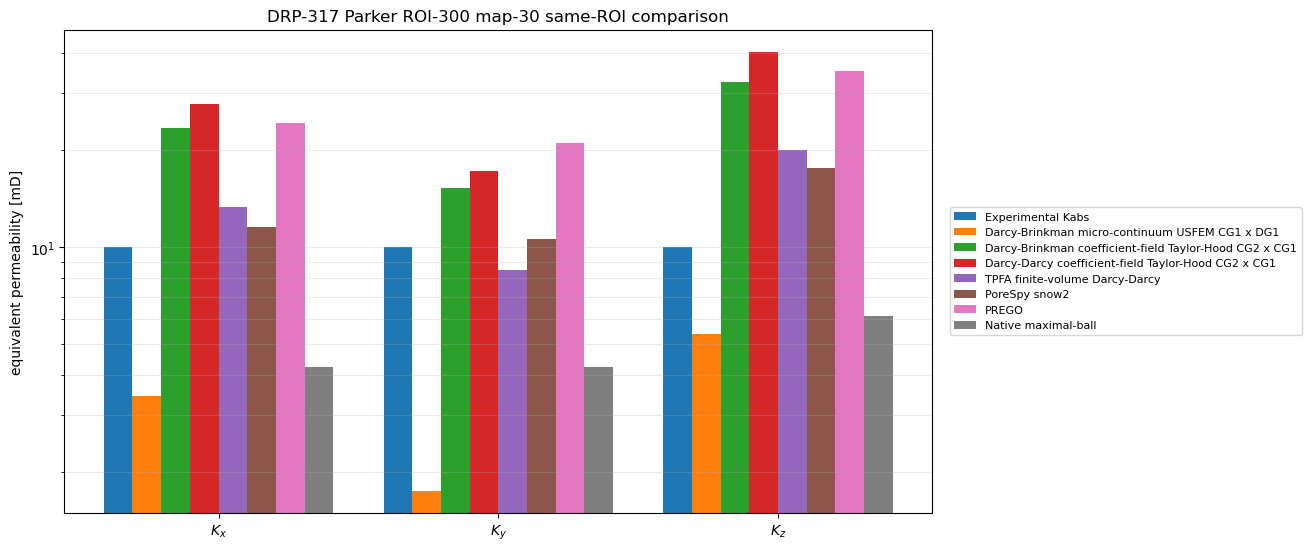

PosixPath('/prj/thermophase/volpatto/Work/voids/notebooks/outputs/44_mwe_drp317_parker_roi300_map30_same_roi_comparison/drp317_parker_roi300_map30_same_roi_model_comparison.png')

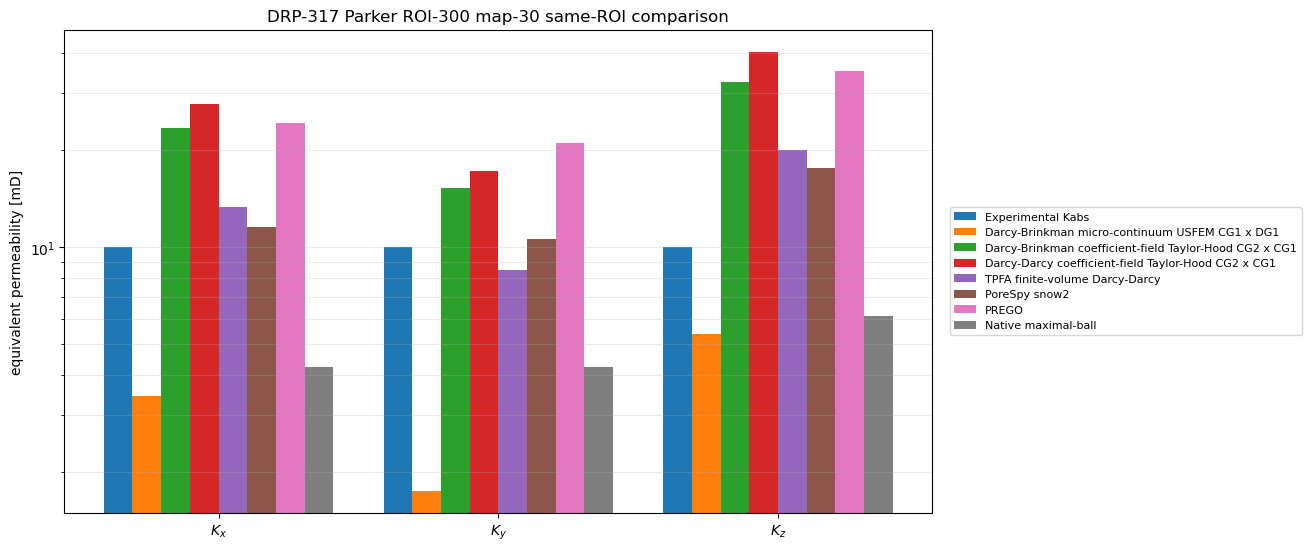

In [14]:
fig, ax = plt.subplots(figsize=(13, 5.4), constrained_layout=True)
bar_width = 0.82 / max(len(available_methods), 1)
x_positions = np.arange(len(axis_order), dtype=float)

for method_index, method in enumerate(available_methods):
    subset = comparison_df[comparison_df["method"] == method]
    values = []
    for axis in axis_order:
        match = subset[subset["axis"] == axis]
        values.append(float(match.iloc[0]["K_mD"]) if not match.empty else np.nan)
    offset = (method_index - 0.5 * (len(available_methods) - 1)) * bar_width
    ax.bar(x_positions + offset, values, width=bar_width, label=method)

ax.set_yscale("log")
ax.set_xticks(x_positions)
ax.set_xticklabels([r"$K_x$", r"$K_y$", r"$K_z$"])
ax.set_ylabel("equivalent permeability [mD]")
ax.set_title("DRP-317 Parker ROI-300 map-30 same-ROI comparison")
ax.grid(True, axis="y", which="both", alpha=0.25)
ax.legend(fontsize=8, loc="center left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0.0)

comparison_plot_path = output_dir / f"{output_prefix}_model_comparison.png"
fig.savefig(comparison_plot_path, dpi=200)
display(fig)
comparison_plot_path

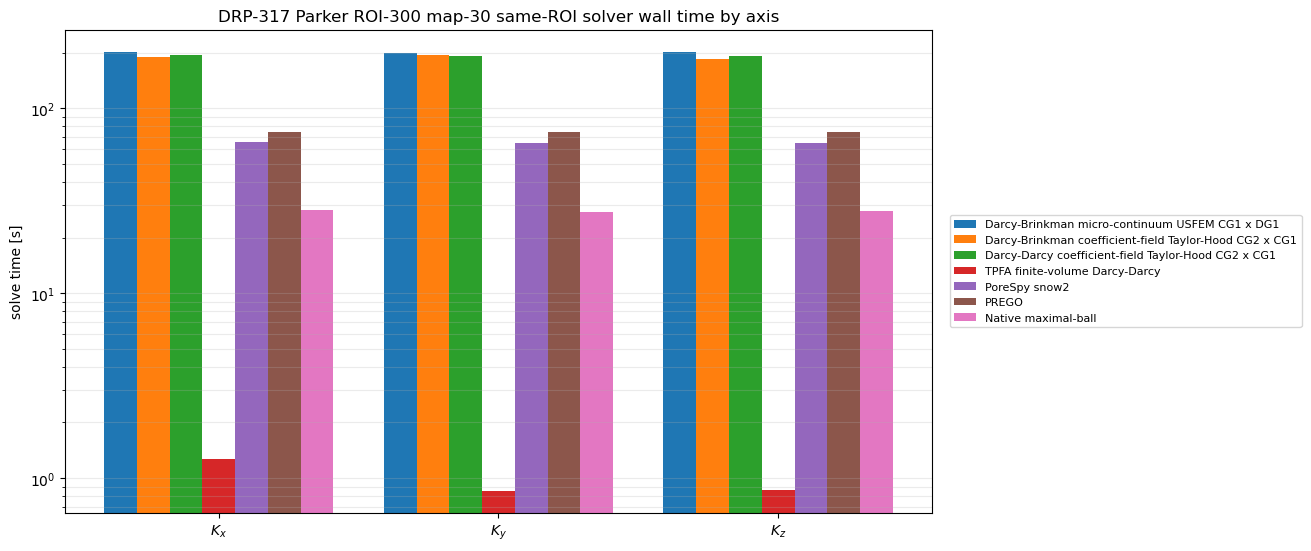

PosixPath('/prj/thermophase/volpatto/Work/voids/notebooks/outputs/44_mwe_drp317_parker_roi300_map30_same_roi_comparison/drp317_parker_roi300_map30_same_roi_model_solve_time.png')

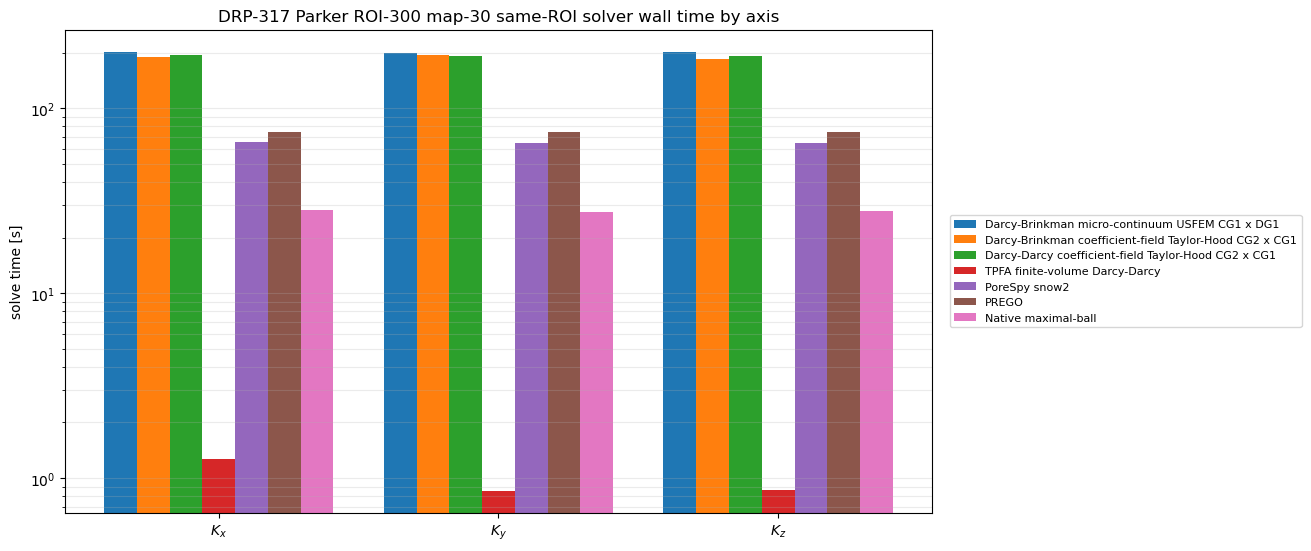

In [15]:
timing_df = comparison_df[np.isfinite(comparison_df["solve_seconds"])].copy()
available_timing_methods = [
    method for method in method_order if method in set(timing_df["method"])
]

fig, ax = plt.subplots(figsize=(13, 5.4), constrained_layout=True)
bar_width = 0.82 / max(len(available_timing_methods), 1)

for method_index, method in enumerate(available_timing_methods):
    subset = timing_df[timing_df["method"] == method]
    values = []
    for axis in axis_order:
        match = subset[subset["axis"] == axis]
        values.append(
            float(match.iloc[0]["solve_seconds"]) if not match.empty else np.nan
        )
    offset = (method_index - 0.5 * (len(available_timing_methods) - 1)) * bar_width
    ax.bar(x_positions + offset, values, width=bar_width, label=method)

ax.set_yscale("log")
ax.set_xticks(x_positions)
ax.set_xticklabels([r"$K_x$", r"$K_y$", r"$K_z$"])
ax.set_ylabel("solve time [s]")
ax.set_title("DRP-317 Parker ROI-300 map-30 same-ROI solver wall time by axis")
ax.grid(True, axis="y", which="both", alpha=0.25)
ax.legend(fontsize=8, loc="center left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0.0)

time_plot_path = output_dir / f"{output_prefix}_model_solve_time.png"
fig.savefig(time_plot_path, dpi=200)
display(fig)
time_plot_path

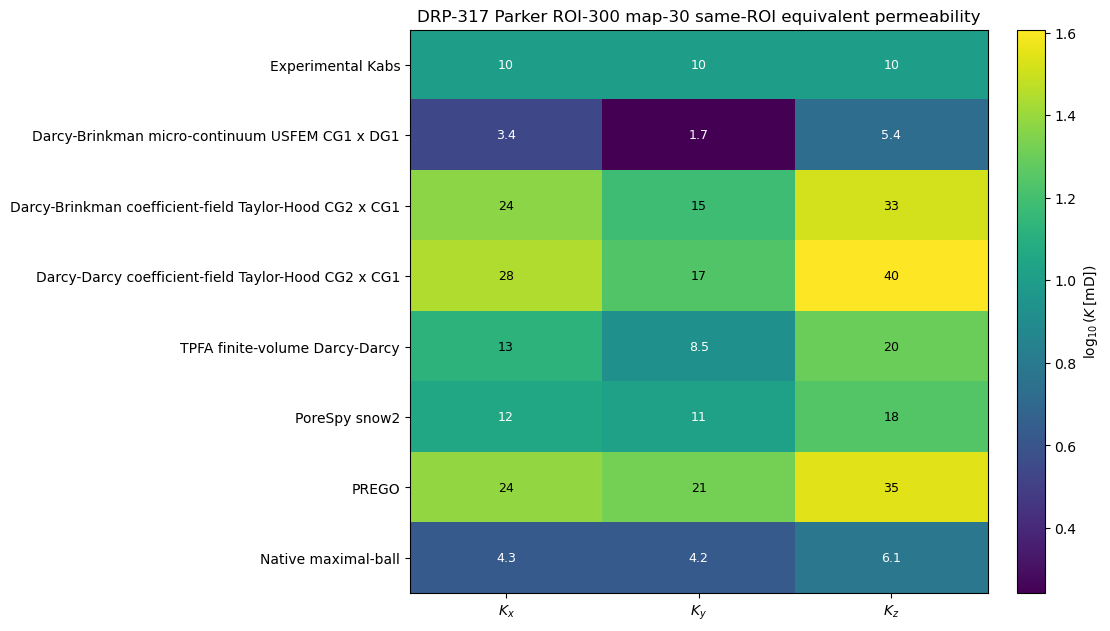

PosixPath('/prj/thermophase/volpatto/Work/voids/notebooks/outputs/44_mwe_drp317_parker_roi300_map30_same_roi_comparison/drp317_parker_roi300_map30_same_roi_model_comparison_heatmap.png')

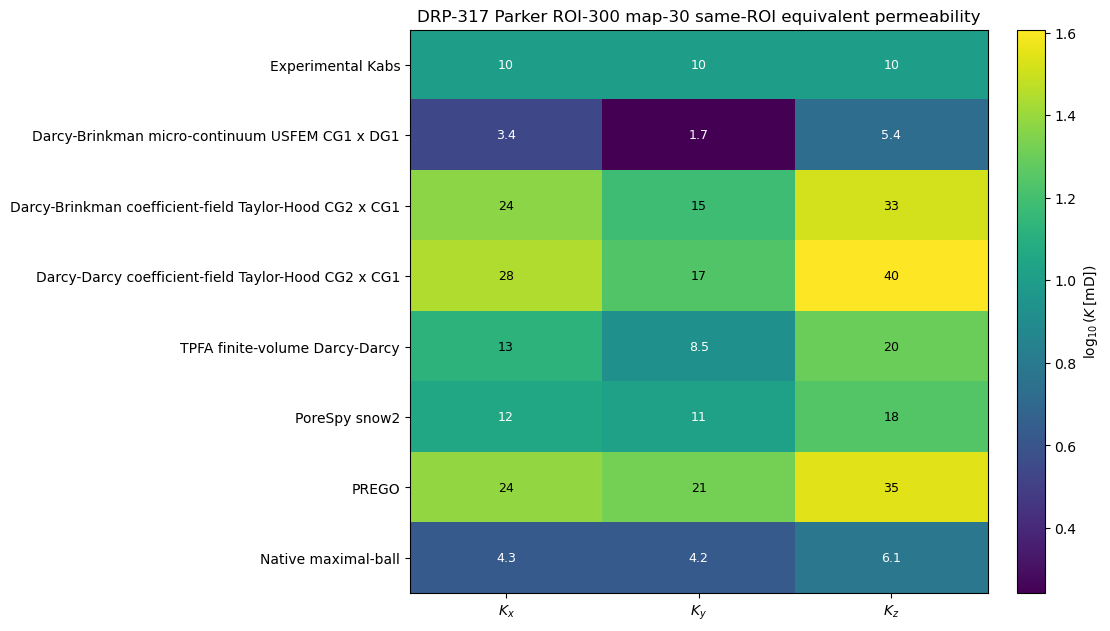

In [16]:
heatmap_df = (
    comparison_df.pivot_table(
        index="method", columns="axis", values="K_mD", aggfunc="first"
    )
    .reindex(available_methods)
    .reindex(columns=axis_order)
)
with np.errstate(divide="ignore", invalid="ignore"):
    heatmap_values = np.log10(heatmap_df.to_numpy(dtype=float))

fig, ax = plt.subplots(figsize=(11, 6.2), constrained_layout=True)
finite_values = heatmap_values[np.isfinite(heatmap_values)]
image = ax.imshow(
    heatmap_values,
    cmap="viridis",
    aspect="auto",
    vmin=float(np.min(finite_values)),
    vmax=float(np.max(finite_values)),
)
ax.set_xticks(np.arange(len(axis_order)))
ax.set_xticklabels([r"$K_x$", r"$K_y$", r"$K_z$"])
ax.set_yticks(np.arange(len(heatmap_df.index)))
ax.set_yticklabels(heatmap_df.index)
ax.set_title("DRP-317 Parker ROI-300 map-30 same-ROI equivalent permeability")
fig.colorbar(image, ax=ax, label=r"$\log_{10}(K\,[\mathrm{mD}])$")

for row_index, method in enumerate(heatmap_df.index):
    for col_index, axis in enumerate(axis_order):
        value = heatmap_df.loc[method, axis]
        if not np.isfinite(value):
            continue
        ax.text(
            col_index,
            row_index,
            f"{value:.2g}",
            ha="center",
            va="center",
            color=(
                "white"
                if heatmap_values[row_index, col_index] < np.median(finite_values)
                else "black"
            ),
            fontsize=9,
        )

comparison_heatmap_path = output_dir / f"{output_prefix}_model_comparison_heatmap.png"
fig.savefig(comparison_heatmap_path, dpi=200)
display(fig)
comparison_heatmap_path

## Save tables

In [17]:
roi_scan_path = output_dir / f"{output_prefix}_scan.csv"
roi_summary_path = output_dir / f"{output_prefix}_summary.csv"
phase_summary_path = output_dir / f"{output_prefix}_phase_summary.csv"
map_summary_path = output_dir / f"{output_prefix}_map_summary.csv"
resistor_path = output_dir / f"{output_prefix}_map_resistor_directional.csv"
pnm_path = output_dir / f"{output_prefix}_pnm_directional.csv"
pnm_failure_path = output_dir / f"{output_prefix}_pnm_failures.csv"
comparison_path = output_dir / f"{output_prefix}_model_comparison.csv"
ratio_path = output_dir / f"{output_prefix}_model_ratios_to_experiment.csv"
bulk_summary_path = output_dir / f"{output_prefix}_bulk_permeability_means.csv"
field_outputs_path = output_dir / f"{output_prefix}_field_outputs.csv"
roi_scan.to_csv(roi_scan_path, index=False)
roi_summary.to_csv(roi_summary_path, index=False)
phase_summary.to_csv(phase_summary_path, index=False)
map_summary.to_csv(map_summary_path, index=False)
resistor_df.to_csv(resistor_path, index=False)
pnm_df.to_csv(pnm_path, index=False)
pnm_failures.to_csv(pnm_failure_path, index=False)
comparison_df.to_csv(comparison_path, index=False)
ratio_df.to_csv(ratio_path, index=False)
bulk_summary_df.to_csv(bulk_summary_path, index=False)
field_outputs_df = pd.DataFrame(field_output_records)
field_outputs_df.to_csv(field_outputs_path, index=False)
fem_status_path.write_text(json.dumps(fem_status, indent=2), encoding="utf-8")
lbm_status_path.write_text(json.dumps(lbm_status, indent=2), encoding="utf-8")

saved_paths = [
    path
    for path in [
        porosity_h5,
        permeability_h5,
        roi_scan_path,
        roi_summary_path,
        phase_summary_path,
        map_summary_path,
        resistor_path,
        pnm_path,
        pnm_failure_path,
        comparison_path,
        ratio_path,
        bulk_summary_path,
        fem_status_path,
        lbm_directional_path,
        lbm_status_path,
        map_figure_path,
        comparison_plot_path,
        bulk_plot_path,
        time_plot_path,
        comparison_heatmap_path,
        field_outputs_path,
        fem_directional_path,
    ]
    if path.exists()
]
for record in field_output_records:
    field_path = Path(str(record["path"]))
    if field_path.exists():
        saved_paths.append(field_path)

for axis, result in resistor_results.items():
    pressure_path = output_dir / f"{output_prefix}_map_resistor_pressure_{axis}.npy"
    np.save(pressure_path, result.pressure)
    saved_paths.append(pressure_path)

pd.DataFrame({"saved_path": [str(path) for path in saved_paths]})

,saved_path
0,/prj/thermophase/volpatto/Work/voids/notebooks...
1,/prj/thermophase/volpatto/Work/voids/notebooks...
2,/prj/thermophase/volpatto/Work/voids/notebooks...
3,/prj/thermophase/volpatto/Work/voids/notebooks...
4,/prj/thermophase/volpatto/Work/voids/notebooks...
...,...
65,/prj/thermophase/volpatto/Work/voids/notebooks...
66,/prj/thermophase/volpatto/Work/voids/notebooks...
67,/prj/thermophase/volpatto/Work/voids/notebooks...
68,/prj/thermophase/volpatto/Work/voids/notebooks...


## Interpretation notes

- All model rows in this notebook use the same cropped binary ROI.
- The `30^3` map uses exact `10^3` voxel block averaging and a Kozeny-Carman closure with characteristic
  length equal to the average map-cell edge.
- The direct-image LBM DNS row uses the binary ROI, pressure reservoirs, and
  bounce-back solids. It does not use the Kozeny-Carman closure field.
- TPFA and LBM full velocity fields are exported as regular-grid VTU files.
  FEM pressure and velocity fields are exported as XDMF/HDF5 files. PNM solves
  are graph-valued and do not produce a full volumetric velocity field.
- The experimental permeability is a bulk scalar for Parker and is repeated
  over the three axes only as a visual reference.
- Because the ROI is small, agreement or disagreement with the bulk experiment
  should be read as a model/ROI sensitivity check, not a sample-scale
  validation.